# HMDA Mortgage Lending — EDA, Baseline Modeling & Fairness Audit

This notebook builds a baseline credit approval classifier on the **Home Mortgage Disclosure Act (HMDA)** dataset and conducts a fairness audit across protected demographic groups.

Binary classification target:
- **1 = Approved** (action_taken 1 or 2)
- **0 = Denied** (action_taken 3)

**Project priority: fairness analysis over predictive performance.**

#### Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Preparation](#2)
3. [Feature Groups](#3)
4. [Exploratory Data Analysis](#4)
5. [Predictive Modeling](#5)
6. [Model Evaluation](#6)
7. [Feature Importance & SHAP](#7)
8. [Fairness Audit](#8)

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from typing import Tuple
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
import xgboost as xgb
import shap

from tabpfn_client import TabPFNClassifier, set_access_token
from getpass import getpass

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
fix_seed = 42

### Connecting to DuckDB

Our data is stored as Parquet files on Google Drive, accessible via a local DuckDB database (`hmda_explorer.duckdb`). DuckDB is an in-process analytical database optimized for large-scale analytical queries and can stream Parquet files directly from disk without loading everything into RAM.

**Important:** Close DBeaver before running this cell — the `.duckdb` file cannot be opened by two processes simultaneously.

In [70]:
DATA_PATH  = Path("/HMDA_data")
OUTPUT_DIR = Path("/hmda_eda_output")
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS   = list(range(2018, 2025))
DB_FILE = "hmda_explorer.duckdb"

In [72]:
# Connect and create views
con = duckdb.connect(DB_FILE)
for year in YEARS:
    fp = DATA_PATH / f"year_{year}.parquet"
    if not fp.exists():
        continue
    con.execute(f"CREATE OR REPLACE VIEW year_{year} AS SELECT * FROM read_parquet('{fp.as_posix()}')")

union_sql = "\nUNION ALL\n".join([f"SELECT * FROM year_{y}" for y in YEARS])
con.execute(f"CREATE OR REPLACE VIEW hmda_all AS {union_sql}")
print("Views ready.")
con.execute("SELECT COUNT(*) AS total_rows FROM hmda_all").fetchdf()

Views ready.


,total_rows
0,124576261


### 1.1 Variable Selection and Sample Query

We load a balanced sample of **200,000 observations (≈ 28,571 per year)** drawn equally from all 7 HMDA vintages (2018–2024).

**Scope filters applied at SQL level:**
- `action_taken IN (1, 2, 3)` = target
- `lien_status = '1'` = first lien mortgages only
- `loan purpose = '1'` = purchase purposes only 
- `occupancy_type = '1'` = owner-occupied principal residences only
- `business_or_commercial_purpose != '1'`, `reverse_mortgage != '1'`, `open-end_line_of_credit != '1'`
- `debt_to_income_ratio != 'Exempt'` = excludes partially exempt institutions (<500 loans/year) with many missing variables 

In [73]:
# Load sample — exactly 200k rows after filters, drawn from all 7 years (2018-2024)
YEARS = list(range(2018, 2025))

cols = """
    action_taken,
    loan_type, loan_amount,
    loan_to_value_ratio, conforming_loan_limit, loan_term,
    property_value, total_units, construction_method,
    income, debt_to_income_ratio,
    applicant_credit_score_type, "co-applicant_credit_score_type",
    submission_of_application,
    ffiec_msa_md_median_family_income, tract_to_msa_income_percentage,
    tract_minority_population_percent, tract_population,
    tract_one_to_four_family_homes, tract_owner_occupied_units,
    tract_median_age_of_housing_units,
    derived_race, derived_sex, derived_ethnicity,
    applicant_age, applicant_age_above_62,
    "co-applicant_race-1", "co-applicant_ethnicity-1",
    "co-applicant_age", "co-applicant_age_above_62", "co-applicant_sex",
    activity_year, state_code, "derived_msa-md", county_code, lei
"""

where = """
    WHERE action_taken IN (1, 2, 3)
    AND lien_status = '1'
    AND occupancy_type = '1'
    AND loan_purpose = '1'
    AND business_or_commercial_purpose != '1'
    AND reverse_mortgage != '1'
    AND "open-end_line_of_credit" != '1'
    AND debt_to_income_ratio != 'Exempt'
"""

blocks = [f"SELECT {cols} FROM year_{yr} {where}" for yr in YEARS]
sql = "SELECT * FROM (\n" + "\nUNION ALL\n".join(blocks) + "\n) USING SAMPLE reservoir(200000 ROWS) REPEATABLE (42)"

con = duckdb.connect(DB_FILE)

con.execute("SET threads = 1;")

df_raw = con.execute(sql).df()

con.execute("SET threads = 1;")

con.close()

print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(df_raw['activity_year'].value_counts().sort_index())


Loaded: 200,000 rows x 36 columns
activity_year
2018    28515
2019    29362
2020    32513
2021    34484
2022    28704
2023    23351
2024    23071
Name: count, dtype: int64


<a id='2'></a>
## 2. Data Preparation

All cleaning and feature engineering steps are encapsulated in `prepare_hmda_data()`. The function handles:
- Type conversion and target variable construction
- Outlier removal (LTV, loan term, income, property value)
- DTI band-string parsing to numeric midpoints
- HMDA special code replacement (1111, 8888, 9999, group-specific codes)
- Co-applicant structural indicator (`has_coapplicant`)
- Missingness indicator variables for MNAR-prone features

In [5]:
def parse_dti(val) -> float:
    """Convert HMDA DTI string encoding to a numeric midpoint.

    Parameters
    ----------
    val : str or float
        Raw DTI value from the HMDA Parquet file.

    Returns
    -------
    float
        Numeric midpoint, or NaN for exempt/unavailable entries.
    """
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace('%', '').replace(' ', '')
    if s in ('NA', 'Exempt', 'na', 'exempt', ''):
        return np.nan
    try:
        return float(s)
    except ValueError:
        pass
    if s.startswith('<'):
        return float(s[1:]) / 2
    if s.startswith('>'):
        return float(s[1:]) + 5
    for sep in ['-<', '-']:
        if sep in s:
            parts = s.split(sep)
            try:
                return (float(parts[0]) + float(parts[1])) / 2
            except:
                pass
    return np.nan

In [ ]:
def prepare_hmda_data(df: pd.DataFrame, verbose: int = 1) -> Tuple[pd.DataFrame, np.ndarray]:
    """Clean and prepare raw HMDA data for modeling and fairness analysis.

    Applies type conversion, outlier removal, DTI parsing, HMDA special code
    replacement, missingness indicator construction, and target variable encoding.

    Parameters
    ----------
    df : pd.DataFrame
        Raw HMDA data as loaded from the DuckDB query.
    verbose : int, optional
        Print progress summary. Default is 1.

    Returns
    -------
    df : pd.DataFrame
        Cleaned dataframe retaining all columns for EDA and fairness audit.
    y : np.ndarray
        Binary target vector (1 = approved, 0 = denied).
    """
    df = df.copy()

    # Type conversion to numeric values
    num_cols = [
        'action_taken', 'loan_type', 'loan_amount',
        'loan_to_value_ratio', 'loan_term', 'property_value', 'total_units',
        'income', 'applicant_credit_score_type', 'co-applicant_credit_score_type',
        'submission_of_application',
        'tract_minority_population_percent', 'tract_population',
        'tract_one_to_four_family_homes', 'tract_owner_occupied_units',
        'tract_median_age_of_housing_units',
        'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Target variable
    df['target'] = df['action_taken'].map({1: 1, 2: 1, 3: 0})

    # Outlier removal
    df.loc[df['income'] < 0, 'income'] = np.nan
    df = df[df['loan_to_value_ratio'] <= 105]
    df = df[df['loan_term'] <= 480]
    df = df[df['income'] <= 1000]
    df = df[df['property_value'] <= 10_000_000]

    # DTI parsing 
    df['dti_numeric'] = df['debt_to_income_ratio'].apply(parse_dti)

    # Structural co-applicant indicator (before replacing code '5')
    df['has_coapplicant'] = (df['co-applicant_sex'] != '5').astype(int)

    # Special code replacements
    df['applicant_credit_score_type']    = df['applicant_credit_score_type'].replace(1111, np.nan)
    df['co-applicant_credit_score_type'] = df['co-applicant_credit_score_type'].replace([1111, 10], np.nan)
    df['submission_of_application']      = df['submission_of_application'].replace(1111, np.nan)
    df['derived_race']      = df['derived_race'].replace(['Race Not Available', 'Free Form Text Only'], np.nan)
    df['derived_ethnicity'] = df['derived_ethnicity'].replace(['Ethnicity Not Available', 'Free Form Text Only'], np.nan)
    df['derived_sex']       = df['derived_sex'].replace('Sex Not Available', np.nan)

    for col in ['applicant_age', 'co-applicant_age']:
        df[col] = df[col].replace(['8888', '9999'], np.nan)
    df['applicant_age_above_62']    = df['applicant_age_above_62'].replace('NA', np.nan)
    df['co-applicant_age_above_62'] = df['co-applicant_age_above_62'].replace('NA', np.nan)

    df['co-applicant_race-1']      = df['co-applicant_race-1'].replace(['6', '7', '8'], np.nan)
    df['co-applicant_ethnicity-1'] = df['co-applicant_ethnicity-1'].replace(['3', '4', '5'], np.nan)
    df['co-applicant_sex']         = df['co-applicant_sex'].replace(['3', '4', '5'], np.nan)

    # Missingness indicators (confirmed by feature importance analysis) ---
    df['dti_missing']      = df['dti_numeric'].isnull().astype(int)

    if verbose:
        print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
        print(f"Approval rate: {df['target'].mean():.1%}")
        print(f"Co-applicant share: {df['has_coapplicant'].mean():.1%}")

    return df, df['target'].values

df, y = prepare_hmda_data(df_raw)

Shape: 179,176 rows x 41 columns
Approval rate: 90.9%
Co-applicant share: 43.9%


<a id='3'></a>
## 3. Feature Groups

Based on **Table 1** (HMDA Variable Selection), we organise all available columns into three groups:

- **`MODEL_FEATURES`** — input features for the classifier
- **`PROTECTED_ATTRS`** — sensitive demographic attributes for fairness audit only; never fed into the model
- **`GROUPING_VARS`** — year, geography, and lender variables for stratified analyses

`co-applicant_race-2` to `-5`, `co-applicant_ethnicity-2` to `-5` are between 98.2% and 100% missing across our sample. These fields carry no meaningful information for the fairness audit and are dropped already in our SQL Select. 

Possibility: `construction_method` and `tract_minority_population_percent` retained for the fairness audit???

In [ ]:
MODEL_FEATURES = [
    'loan_type', 
    'loan_amount', 'loan_to_value_ratio', 'conforming_loan_limit', 'loan_term',
    'property_value', 'total_units',
    'income', 'dti_numeric',
    'applicant_credit_score_type', 'co-applicant_credit_score_type',
    'has_coapplicant', 'submission_of_application',
    'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
    'tract_one_to_four_family_homes',
    'dti_missing',
]

PROTECTED_ATTRS = [
    'derived_race', 'derived_sex', 'derived_ethnicity',
    'applicant_age', 'applicant_age_above_62',
    'co-applicant_race-1', 'co-applicant_ethnicity-1',
    'co-applicant_age', 'co-applicant_age_above_62', 'co-applicant_sex',
]

GROUPING_VARS   = ['activity_year', 'state_code', 'derived_msa-md', 'county_code', 'lei']
# FAIRNESS_CTX    = ['tract_minority_population_percent', 'construction_method']

print(f'Model features:  {len(MODEL_FEATURES)}')
print(f'Protected attrs: {len(PROTECTED_ATTRS)}')

Model features:  18
Protected attrs: 10


In [8]:
# Missing value overview for model features and protected attributes
model_cols = [c for c in MODEL_FEATURES if c in df.columns]

miss = df[model_cols].isnull().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
print("Model feature missingness (%):")
print(miss.round(2).to_string())

print("\nProtected attribute missingness (%):")
prot_miss = df[[c for c in PROTECTED_ATTRS if c in df.columns]].isnull().mean().mul(100).sort_values(ascending=False)
print(prot_miss[prot_miss > 0].round(1).to_string())
print("\nNote: co-applicant fields ~57% missing = structural (no co-applicant); covered by has_coapplicant.")
print("      derived_race, ethnicity missing: how deal with them in modeling and fairness audit?")

Model feature missingness (%):
co-applicant_credit_score_type    56.09
dti_numeric                        0.32
submission_of_application          0.01
applicant_credit_score_type        0.00
total_units                        0.00

Protected attribute missingness (%):
co-applicant_race-1          62.6
co-applicant_ethnicity-1     62.4
co-applicant_sex             59.0
co-applicant_age             56.1
co-applicant_age_above_62    56.1
derived_race                 13.1
derived_ethnicity            12.5
derived_sex                   5.4
applicant_age_above_62        0.0
applicant_age                 0.0

Note: co-applicant fields ~57% missing = structural (no co-applicant); covered by has_coapplicant.
      derived_race, ethnicity missing: how deal with them in modeling and fairness audit?


<a id='4'></a>
## 4. Exploratory Data Analysis

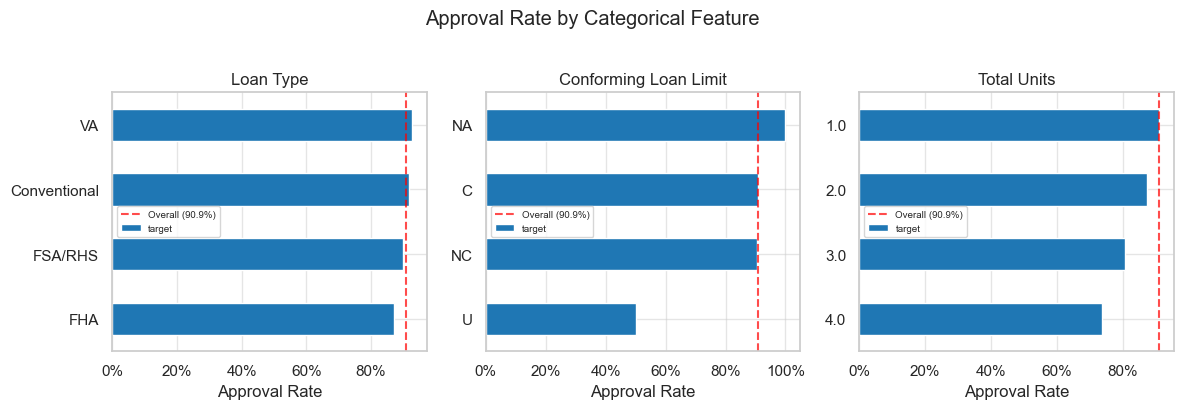

In [9]:
# Approval rate by categorical features
loan_type_labels    = {1: 'Conventional', 2: 'FHA', 3: 'VA', 4: 'FSA/RHS'}
# loan_purpose_labels = {1: 'Purchase', 2: 'Home Improvement', 31: 'Refinancing', 32: 'Cash-out Refi', 4: 'Other'}
df['loan_type_label']    = df['loan_type'].map(loan_type_labels)
#df['loan_purpose_label'] = df['loan_purpose'].map(loan_purpose_labels)

cat_features = ['loan_type_label', 'conforming_loan_limit', 'total_units']
cat_present  = [c for c in cat_features if c in df.columns]
overall_rate = df['target'].mean()

fig, axes = plt.subplots(1, len(cat_present), figsize=(4 * len(cat_present), 4))
for ax, col in zip(axes, cat_present):
    rates = df.groupby(col)['target'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='white')
    ax.axvline(overall_rate, color='red', linestyle='--', alpha=0.7, label=f'Overall ({overall_rate:.1%})')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(col.replace('_label', '').replace('_', ' ').title())
    ax.set_xlabel('Approval Rate')
    ax.set_ylabel('')
    ax.legend(fontsize=7)
plt.suptitle('Approval Rate by Categorical Feature', y=1.02)
plt.tight_layout()
plt.show()

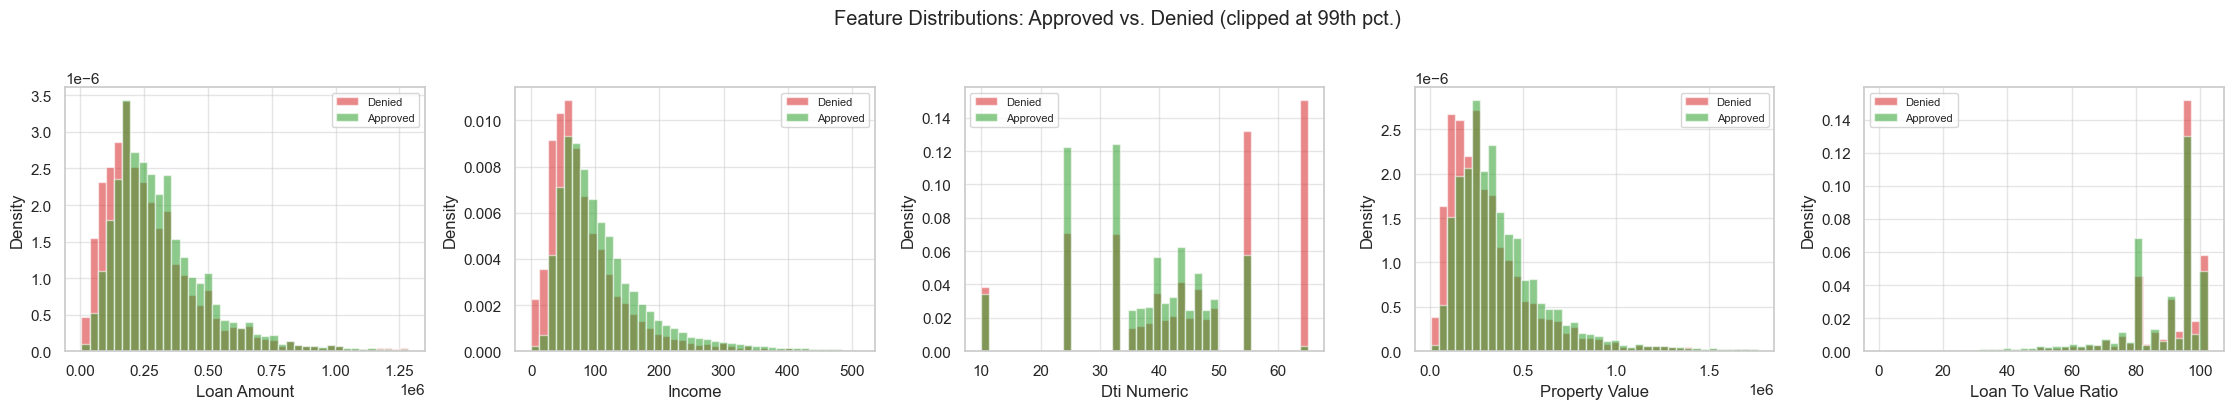

In [10]:
# Numerical feature distributions: approved vs denied
num_features = ['loan_amount', 'income', 'dti_numeric', 'property_value', 'loan_to_value_ratio']
num_present  = [c for c in num_features if c in df.columns]

fig, axes = plt.subplots(1, len(num_present), figsize=(4.5 * len(num_present), 4))
for ax, col in zip(axes, num_present):
    tmp = df[[col, 'target']].dropna()
    tmp = tmp[tmp[col] <= tmp[col].quantile(0.99)]
    for label, color, name in [(0, '#d62728', 'Denied'), (1, '#2ca02c', 'Approved')]:
        ax.hist(tmp[tmp['target'] == label][col], bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions: Approved vs. Denied (clipped at 99th pct.)', y=1.02)
plt.tight_layout()
plt.show()

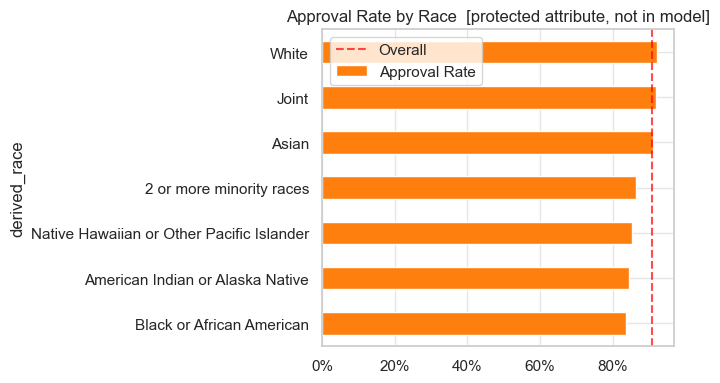

In [11]:
# Raw approval rates by race (descriptive analysis of protected attribute, not for modeling)
rates = (df.groupby('derived_race')['target']
           .agg(['mean', 'count'])
           .rename(columns={'mean': 'Approval Rate', 'count': 'N'})
           .query('N > 100')
           .sort_values('Approval Rate'))

fig, ax = plt.subplots(figsize=(7, 4))
rates['Approval Rate'].plot(kind='barh', ax=ax, color='#ff7f0e', edgecolor='white')
ax.axvline(df['target'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Approval Rate by Race  [protected attribute, not in model]')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Vergleich der key underwriting features nach Race
features_to_check = ['dti_numeric', 'loan_to_value_ratio', 'income', 'loan_amount']
print(df.groupby('derived_race')[features_to_check]
      .median().round(1)
      .sort_values('dti_numeric', ascending=False))

NameError: name 'fairness_df' is not defined

### Summary Statistics

A `df.describe()`-style overview of all 18 model features is a standard EDA prerequisite — it reveals scale differences, outlier presence, and missingness at a glance.

In [ ]:
# Summary statistics for all model features
model_cols_present = [c for c in MODEL_FEATURES if c in df.columns]

# Numeric features: full describe
num_feats = [c for c in model_cols_present if pd.api.types.is_numeric_dtype(df[c])]
desc = df[num_feats].describe(percentiles=[.25, .5, .75, .95]).T.round(2)
desc.insert(0, 'missing%', df[num_feats].isnull().mean().mul(100).round(1))
desc.columns.name = None

print("═" * 90)
print("Model Feature Summary Statistics — Numeric Features")
print("═" * 90)
display(desc)

# Categorical features: value counts + approval rate
cat_feats = [c for c in model_cols_present if not pd.api.types.is_numeric_dtype(df[c])]
if cat_feats:
    print("\nCategorical Features — Value Distribution:")
    for col in cat_feats:
        vc   = df[col].value_counts(dropna=False).rename('N')
        rate = df.groupby(col, dropna=False)['target'].mean().rename('Approval Rate')
        print(f"\n  {col}:")
        print(pd.concat([vc, rate], axis=1).sort_values('N', ascending=False)
              .assign(**{'N%': lambda x: (x['N'] / len(df) * 100).round(1)})
              [['N', 'N%', 'Approval Rate']].round(3).to_string(index=True))

══════════════════════════════════════════════════════════════════════════════════════════
Model Feature Summary Statistics — Numeric Features
══════════════════════════════════════════════════════════════════════════════════════════


,missing%,count,mean,std,min,25%,50%,75%,95%,max
loan_type,0.0,179588.0,1.45,0.75,1.0,1.0,1.00,2.00,3.0,4.00
loan_amount,0.0,179588.0,326325.42,244024.10,5000.0,185000.0,275000.00,395000.00,725000.0,6655000.00
loan_to_value_ratio,0.0,179588.0,86.62,15.05,0.8,80.0,93.77,96.50,100.0,105.00
loan_term,0.0,179588.0,351.05,39.28,1.0,360.0,360.00,360.00,360.0,480.00
property_value,0.0,179588.0,398489.82,343426.86,5000.0,205000.0,315000.00,475000.00,935000.0,9505000.00
total_units,0.0,179588.0,1.02,0.16,1.0,1.0,1.00,1.00,1.0,4.00
income,0.0,179588.0,115.21,94.63,0.0,59.0,89.00,137.00,284.0,1000.00
dti_numeric,0.3,178994.0,38.19,11.35,10.0,33.0,39.00,46.00,55.0,65.00
applicant_credit_score_type,0.0,179583.0,2.76,2.25,1.0,1.0,2.00,3.00,9.0,15.00
co-applicant_credit_score_type,56.0,79072.0,5.80,3.50,1.0,2.0,9.00,9.00,9.0,15.00



Categorical Features — Value Distribution:

  conforming_loan_limit:
                            N    N%  Approval Rate
conforming_loan_limit                             
C                      170566  95.0          0.910
NC                       9004   5.0          0.908
U                          18   0.0          0.444


### Target Variable Imbalance

The dataset has a **91.1% approval rate** — a highly imbalanced binary target. This directly motivates `class_weight='balanced'` for Logistic Regression and a `scale_pos_weight` of ≈0.10 for XGBoost. AUPRC is a more informative evaluation metric than AUC under severe class imbalance.

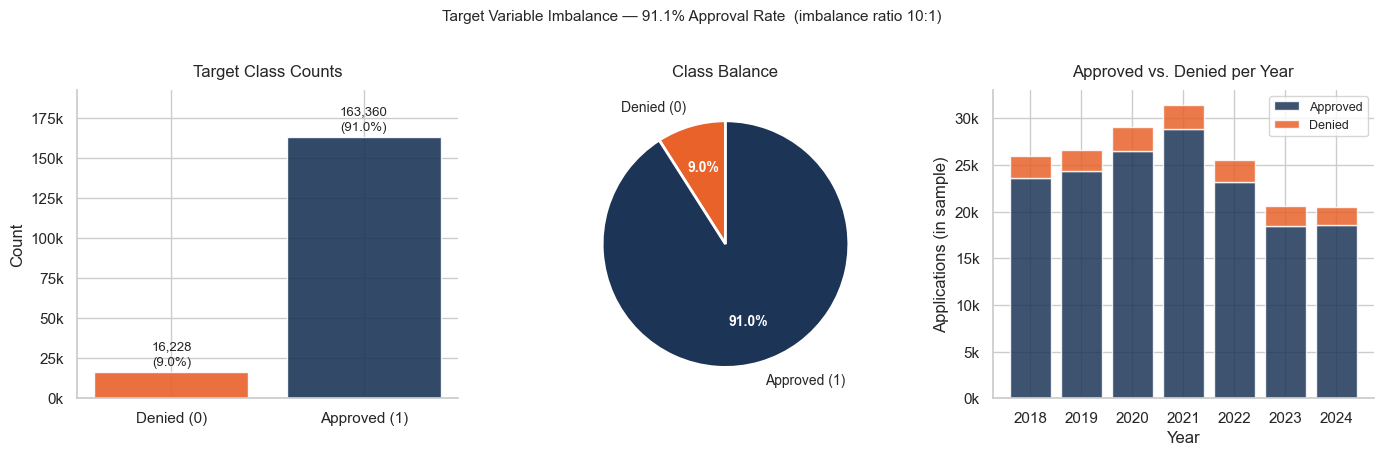

Denied:   16,228  (9.0%)
Approved: 163,360  (91.0%)
Imbalance ratio: 10.1:1  →  scale_pos_weight for XGBoost: 0.099


In [ ]:
# Target variable class distribution
counts = pd.Series(y).value_counts().sort_index()
bar_colors = ['#e8622a', '#1c3557']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    f'Target Variable Imbalance — 91.1% Approval Rate  '
    f'(imbalance ratio {counts[1]/counts[0]:.0f}:1)',
    fontsize=11, y=1.01
)

# Bar chart
ax = axes[0]
bars = ax.bar(['Denied (0)', 'Approved (1)'], counts.values,
              color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_title('Target Class Counts', pad=10)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.015,
        f'{v:,}\n({v/len(y):.1%})',
        ha='center', va='bottom', fontsize=9.5, linespacing=1.4
    )

# Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=['Denied (0)', 'Approved (1)'],
    colors=bar_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.65,
    labeldistance=1.15,
)
for t in texts:
    t.set_fontsize(10)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Class Balance', pad=10)

# Stacked bar by year
ax = axes[2]
year_counts = df.groupby('activity_year')['target'].agg(['sum', 'count'])
year_counts['denied'] = year_counts['count'] - year_counts['sum']
ax.bar(year_counts.index, year_counts['sum'],
       label='Approved', color='#1c3557', alpha=0.85)
ax.bar(year_counts.index, year_counts['denied'],
       label='Denied', color='#e8622a', alpha=0.85,
       bottom=year_counts['sum'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Approved vs. Denied per Year', pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('Applications (in sample)')
ax.set_xticks(year_counts.index)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9, framealpha=0.8, loc='upper right')

plt.tight_layout()
plt.show()
print(f"Denied:   {counts[0]:,}  ({counts[0]/len(y):.1%})")
print(f"Approved: {counts[1]:,}  ({counts[1]/len(y):.1%})")
print(f"Imbalance ratio: {counts[1]/counts[0]:.1f}:1  →  scale_pos_weight for XGBoost: {counts[0]/counts[1]:.3f}")

### Temporal / Longitudinal Analysis (2018–2024)

Seven years of data are available but approval trends over time have not been examined. Application volumes, overall approval rates, and the racial approval gap may have shifted significantly across the 2020 pandemic, the 2022 rate shock, and subsequent cooling.

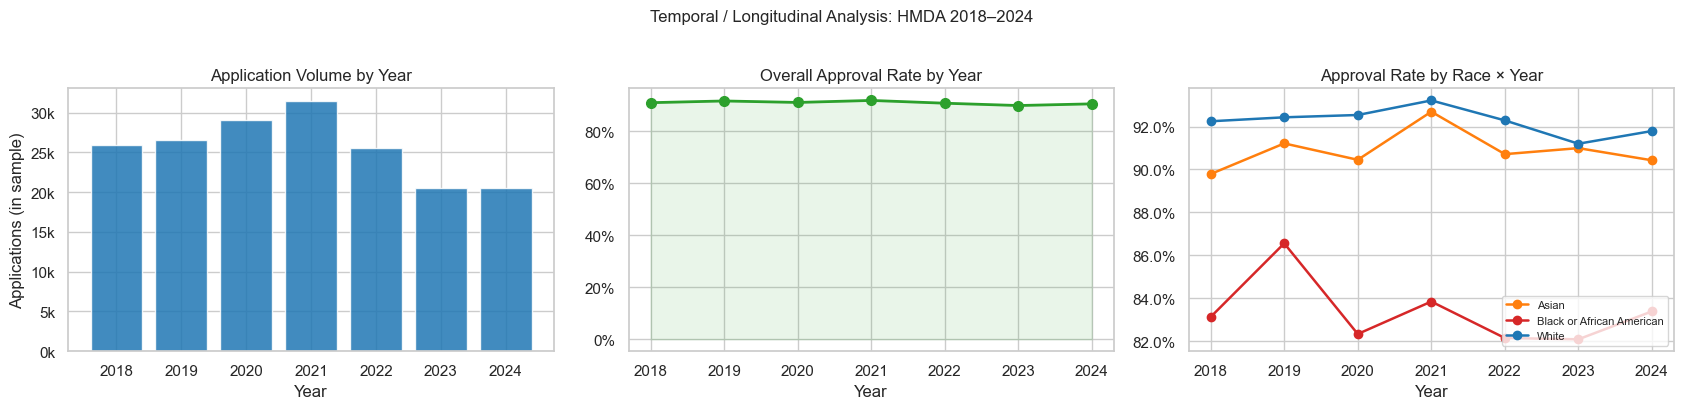

,N,Approval Rate,Asian Approval,Black Approval,White Approval,White–Black Gap
activity_year,,,,,,
2018,"25,923",90.9%,89.8%,83.1%,92.2%,+9.1%
2019,"26,537",91.6%,91.2%,86.6%,92.4%,+5.9%
2020,"29,100",91.0%,90.5%,82.3%,92.5%,+10.2%
2021,"31,445",91.8%,92.7%,83.8%,93.2%,+9.4%
2022,"25,515",90.7%,90.7%,82.2%,92.3%,+10.1%
2023,"20,560",89.8%,91.0%,82.1%,91.2%,+9.1%
2024,"20,508",90.5%,90.4%,83.4%,91.8%,+8.4%


In [ ]:
# Temporal trends: volume, overall approval rate, and race-stratified approval 2018-2024
yearly = df.groupby('activity_year').agg(
    n=('target', 'count'),
    approval_rate=('target', 'mean'),
).reset_index()

race_year = (
    df[df['derived_race'].isin(['White', 'Black or African American', 'Asian'])]
    .groupby(['activity_year', 'derived_race'])['target']
    .mean().unstack()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Application volume
axes[0].bar(yearly['activity_year'], yearly['n'], color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Application Volume by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Applications (in sample)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].set_xticks(yearly['activity_year'])

# Overall approval rate
axes[1].plot(yearly['activity_year'], yearly['approval_rate'],
             marker='o', color='#2ca02c', linewidth=2, markersize=7)
axes[1].fill_between(yearly['activity_year'], yearly['approval_rate'],
                     alpha=0.1, color='#2ca02c')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Overall Approval Rate by Year')
axes[1].set_xlabel('Year')
axes[1].set_xticks(yearly['activity_year'])

# Race-stratified approval rates
palette = {'White': '#1f77b4', 'Black or African American': '#d62728', 'Asian': '#ff7f0e'}
for col in race_year.columns:
    axes[2].plot(race_year.index, race_year[col], marker='o',
                 label=col, linewidth=1.8, color=palette.get(col, 'gray'))
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].set_title('Approval Rate by Race × Year')
axes[2].set_xlabel('Year')
axes[2].legend(fontsize=8, loc='lower right')
axes[2].set_xticks(race_year.index)

plt.suptitle('Temporal / Longitudinal Analysis: HMDA 2018–2024', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Year-level summary table
race_gap = race_year.copy()
if 'White' in race_gap.columns and 'Black or African American' in race_gap.columns:
    race_gap['White–Black Gap'] = race_gap['White'] - race_gap['Black or African American']
display(yearly.set_index('activity_year')
        .rename(columns={'n': 'N', 'approval_rate': 'Approval Rate'})
        .join(race_gap.rename(columns={'White': 'White Approval', 'Black or African American': 'Black Approval', 'Asian': 'Asian Approval'}))
        .style.format({'Approval Rate': '{:.1%}', 'N': '{:,.0f}',
                       'White Approval': '{:.1%}', 'Black Approval': '{:.1%}',
                       'Asian Approval': '{:.1%}', 'White–Black Gap': '{:+.1%}'}))

### Demographic Breakdowns Beyond Race

`derived_sex`, `derived_ethnicity`, and `applicant_age` are all declared protected attributes but have never been explored in the EDA. No approval rates, no distribution plots. This section addresses this gap for all three attributes.

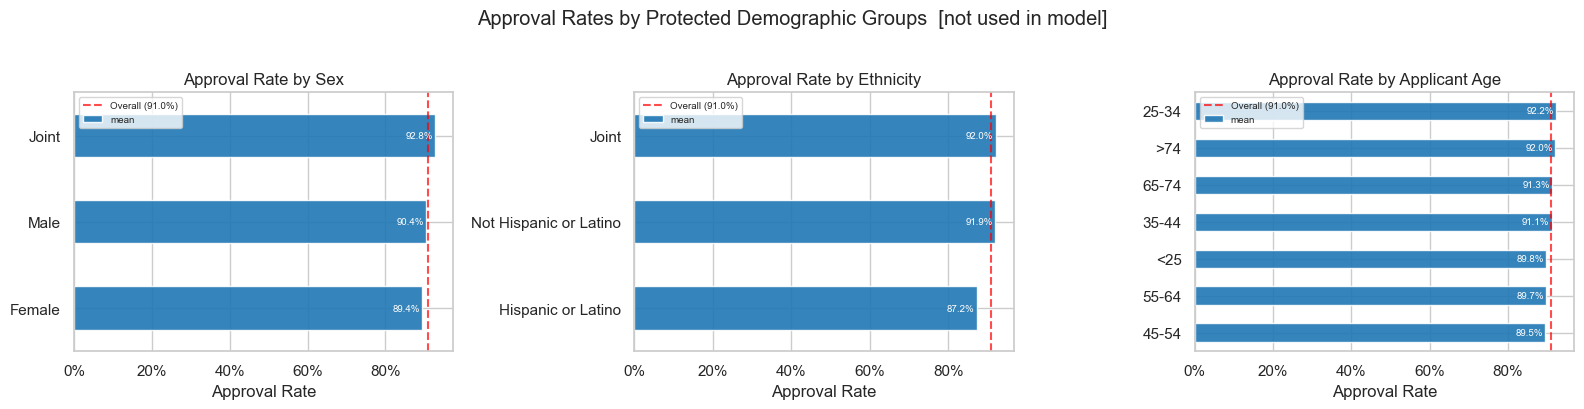

Sample sizes per group:

Sex (derived_sex):
                 N  Approval Rate
derived_sex                      
NaN           9725          0.885
Female       41477          0.894
Male         60987          0.904
Joint        67399          0.928

Ethnicity (derived_ethnicity):
                             N  Approval Rate
derived_ethnicity                            
Hispanic or Latino       22004          0.872
NaN                      22138          0.889
Not Hispanic or Latino  130497          0.919
Joint                     4949          0.920

Applicant Age (applicant_age):
                   N  Approval Rate
applicant_age                      
NaN               21          0.524
45-54          29744          0.895
55-64          19291          0.897
<25            11168          0.898
35-44          48036          0.911
65-74           9720          0.913
>74             2625          0.920
25-34          58983          0.922


In [ ]:
# Approval rates by sex, ethnicity, and age
demo_attrs = [
    ('derived_sex',       'Sex'),
    ('derived_ethnicity', 'Ethnicity'),
    ('applicant_age',     'Applicant Age'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, label) in zip(axes, demo_attrs):
    tmp = df.dropna(subset=[col])
    rates = tmp.groupby(col)['target'].agg(['mean', 'count'])
    rates = rates[rates['count'] > 100].sort_values('mean')
    rates['mean'].plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='white', alpha=0.9)
    ax.axvline(df['target'].mean(), color='red', linestyle='--', alpha=0.7,
               label=f'Overall ({df["target"].mean():.1%})')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Approval Rate by {label}')
    ax.set_xlabel('Approval Rate')
    ax.set_ylabel('')
    ax.legend(fontsize=7)
    for i, (idx, row) in enumerate(rates.iterrows()):
        ax.text(row['mean'] - 0.005, i, f'{row["mean"]:.1%}', va='center', ha='right', fontsize=7, color='white')

plt.suptitle('Approval Rates by Protected Demographic Groups  [not used in model]', y=1.02)
plt.tight_layout()
plt.show()

# Distribution counts for each attribute
print("Sample sizes per group:")
for col, label in demo_attrs:
    print(f"\n{label} ({col}):")
    vc = df[col].value_counts(dropna=False).rename('N')
    rate = df.groupby(col, dropna=False)['target'].mean().rename('Approval Rate')
    print(pd.concat([vc, rate], axis=1).sort_values('Approval Rate').round(3).to_string())

### Co-Applicant Analysis

Co-applicants are present in **43.8%** of applications, yet their effect on approval rates, income pooling, and racial composition has not been explored. This matters for the fairness audit: co-applicant patterns differ systematically by race, which could confound the demographic parity analysis.

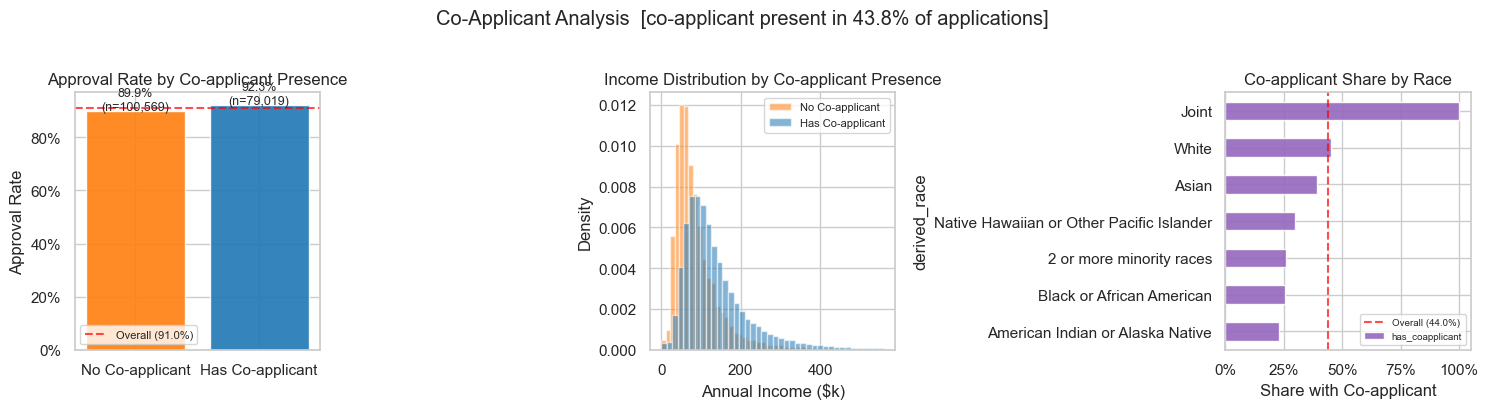

Co-applicant summary statistics:
                  Approval Rate  Median Income ($k)  Median Loan ($k)  Median DTI
has_coapplicant                                                                  
No co-applicant           0.899                72.0          235000.0        40.0
Has co-applicant          0.923               114.0          315000.0        38.0


In [ ]:
# Co-applicant presence vs. approval, income, and race
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Approval rate with/without co-applicant
coapp_rates = df.groupby('has_coapplicant')['target'].mean()
coapp_counts = df.groupby('has_coapplicant')['target'].count()
labels = ['No Co-applicant', 'Has Co-applicant']
bar_colors = ['#ff7f0e', '#1f77b4']
axes[0].bar(labels, coapp_rates.values, color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].axhline(df['target'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall ({df["target"].mean():.1%})')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Approval Rate by Co-applicant Presence')
axes[0].set_ylabel('Approval Rate')
axes[0].legend(fontsize=8)
for i, (v, n) in enumerate(zip(coapp_rates.values, coapp_counts.values)):
    axes[0].text(i, v + 0.003, f'{v:.1%}\n(n={n:,})', ha='center', fontsize=9)

# Income distribution: with/without co-applicant
for label, val, color in [('No Co-applicant', 0, '#ff7f0e'), ('Has Co-applicant', 1, '#1f77b4')]:
    tmp = df[df['has_coapplicant'] == val]['income'].dropna()
    tmp = tmp[tmp <= tmp.quantile(0.99)]
    axes[1].hist(tmp, bins=40, alpha=0.55, color=color, label=label, density=True)
axes[1].set_title('Income Distribution by Co-applicant Presence')
axes[1].set_xlabel('Annual Income ($k)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Race breakdown: share with co-applicant
race_coapp = (
    df.dropna(subset=['derived_race'])
    .groupby('derived_race')['has_coapplicant']
    .mean()
    .sort_values(ascending=True)
)
race_coapp.plot(kind='barh', ax=axes[2], color='#9467bd', edgecolor='white', alpha=0.9)
axes[2].axvline(df['has_coapplicant'].mean(), color='red', linestyle='--', alpha=0.7,
                label=f'Overall ({df["has_coapplicant"].mean():.1%})')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].set_title('Co-applicant Share by Race')
axes[2].set_xlabel('Share with Co-applicant')
axes[2].legend(fontsize=7)

plt.suptitle('Co-Applicant Analysis  [co-applicant present in 43.8% of applications]', y=1.02)
plt.tight_layout()
plt.show()

print("Co-applicant summary statistics:")
print(df.groupby('has_coapplicant')[['target', 'income', 'loan_amount', 'dti_numeric']]
      .agg({'target': 'mean', 'income': 'median', 'loan_amount': 'median', 'dti_numeric': 'median'})
      .rename(index={0: 'No co-applicant', 1: 'Has co-applicant'})
      .rename(columns={'target': 'Approval Rate', 'income': 'Median Income ($k)',
                       'loan_amount': 'Median Loan ($k)', 'dti_numeric': 'Median DTI'})
      .round(3).to_string())

### Correlation Matrix & Feature Relationships

No prior exploration of pairwise feature relationships. For credit modeling, understanding how DTI correlates with income or how loan amount correlates with property value is essential for detecting multicollinearity and guiding feature engineering decisions.

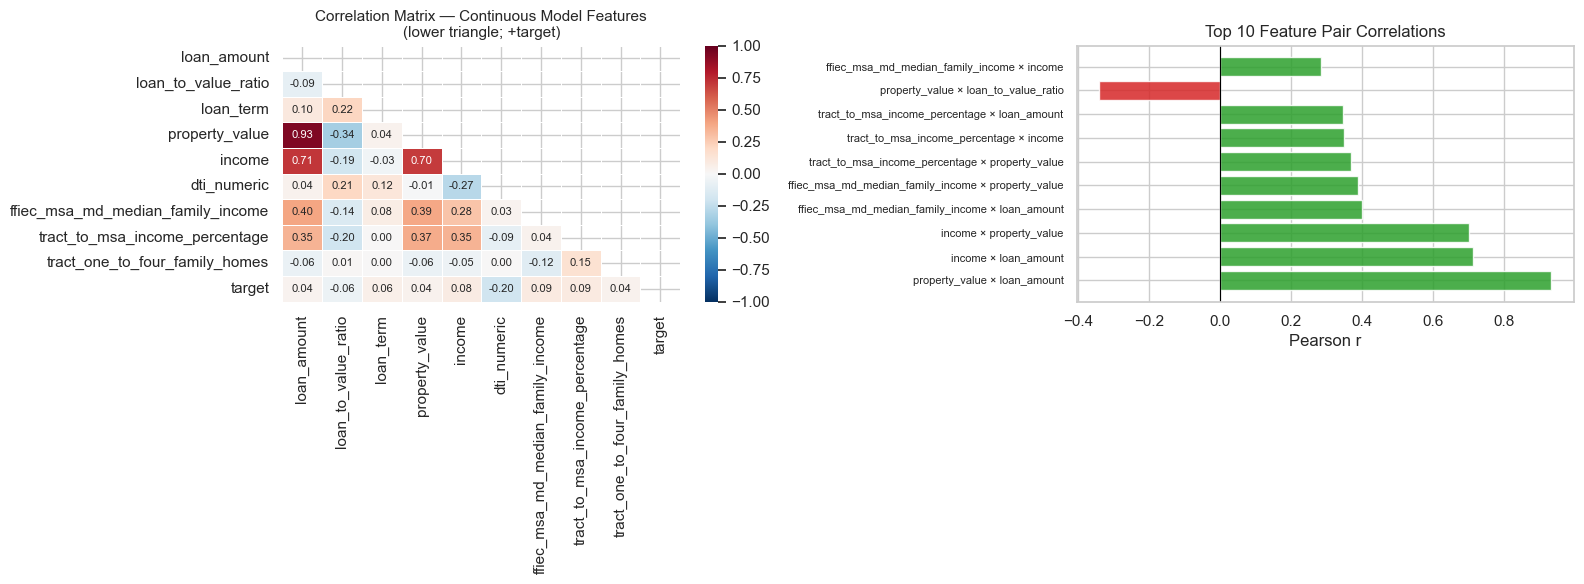

Top 10 absolute feature-pair correlations:
                        Feature A           Feature B      corr
                   property_value         loan_amount  0.932605
                           income         loan_amount  0.710943
                           income      property_value  0.701462
ffiec_msa_md_median_family_income         loan_amount  0.398084
ffiec_msa_md_median_family_income      property_value  0.387299
   tract_to_msa_income_percentage      property_value  0.367717
   tract_to_msa_income_percentage              income  0.347885
   tract_to_msa_income_percentage         loan_amount  0.346633
                   property_value loan_to_value_ratio -0.340076
ffiec_msa_md_median_family_income              income  0.284133


In [ ]:
# Correlation matrix for continuous model features
continuous_features = [
    'loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value',
    'income', 'dti_numeric',
    'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
    'tract_one_to_four_family_homes',
]
cont_present = [c for c in continuous_features if c in df.columns]
corr = df[cont_present + ['target']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Correlation Matrix — Continuous Model Features\n(lower triangle; +target)', fontsize=11)

# Top feature pairs by absolute correlation (excluding target)
feat_corr = df[cont_present].corr()
pairs = (feat_corr.where(np.tril(np.ones(feat_corr.shape), -1).astype(bool))
         .stack()
         .rename('corr')
         .reset_index()
         .assign(abs_corr=lambda x: x['corr'].abs())
         .sort_values('abs_corr', ascending=False)
         .head(10))
pairs['label'] = pairs['level_0'].str.replace('_', '\n') + '\nvs\n' + pairs['level_1'].str.replace('_', '\n')
colors_corr = ['#d62728' if v < 0 else '#2ca02c' for v in pairs['corr']]
axes[1].barh(range(len(pairs)), pairs['corr'].values, color=colors_corr, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(pairs)))
axes[1].set_yticklabels([f"{r['level_0']} × {r['level_1']}" for _, r in pairs.iterrows()], fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('Top 10 Feature Pair Correlations')

plt.tight_layout()
plt.show()

print("Top 10 absolute feature-pair correlations:")
print(pairs[['level_0', 'level_1', 'corr']].rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B'}).to_string(index=False))

### Geographic Variation

The dataset carries rich geographic identifiers (`state_code`, `derived_msa-md`, `county_code`). State-level approval rates reveal whether lending disparities are geographically clustered — a key input for any regulatory or policy interpretation of the fairness audit.

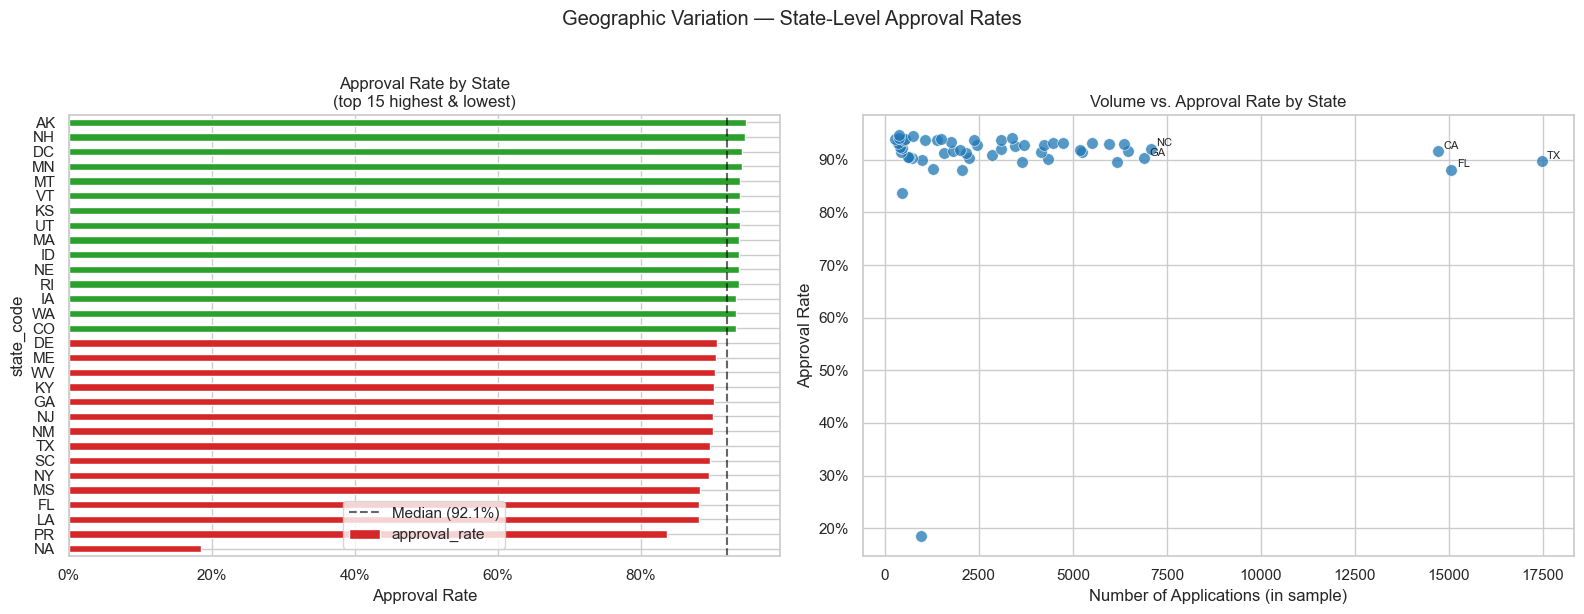

States with ≥200 apps: 53
Approval rate range:   18.5% — 94.7%
Std dev across states: 0.103

Bottom 5 states (lowest approval):
                N  Approval Rate
state_code                      
NA            967          0.185
PR            452          0.836
LA           2034          0.881
FL          15068          0.881
MS           1263          0.882

Top 5 states (highest approval):
               N  Approval Rate
state_code                     
MT           540          0.939
MN          3375          0.941
DC           360          0.942
NH           738          0.946
AK           378          0.947


In [ ]:
# State-level approval rates and volumes
state_stats = (
    df.groupby('state_code')['target']
    .agg(n='count', approval_rate='mean')
    .query('n >= 200')
    .sort_values('approval_rate')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top/bottom 15 states by approval rate
top15    = state_stats.nlargest(15, 'approval_rate')
bottom15 = state_stats.nsmallest(15, 'approval_rate')
combined = pd.concat([bottom15, top15]).drop_duplicates().sort_values('approval_rate')
median_rate = state_stats['approval_rate'].median()
colors_geo = ['#d62728' if v < median_rate else '#2ca02c'
              for v in combined['approval_rate'].values]

combined['approval_rate'].plot(kind='barh', ax=axes[0], color=colors_geo, edgecolor='white')
axes[0].axvline(median_rate, color='black', linestyle='--', alpha=0.6, label=f'Median ({median_rate:.1%})')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Approval Rate by State\n(top 15 highest & lowest)')
axes[0].set_xlabel('Approval Rate')
axes[0].legend()

# Volume vs. approval rate scatter
axes[1].scatter(state_stats['n'], state_stats['approval_rate'],
                alpha=0.75, color='#1f77b4', s=70, edgecolors='white', linewidths=0.5)
for state in state_stats.nlargest(5, 'n').index:
    row = state_stats.loc[state]
    axes[1].annotate(state, (row['n'], row['approval_rate']),
                     textcoords='offset points', xytext=(4, 2), fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('Number of Applications (in sample)')
axes[1].set_ylabel('Approval Rate')
axes[1].set_title('Volume vs. Approval Rate by State')

plt.suptitle('Geographic Variation — State-Level Approval Rates', y=1.02)
plt.tight_layout()
plt.show()

print(f"States with ≥200 apps: {len(state_stats)}")
print(f"Approval rate range:   {state_stats['approval_rate'].min():.1%} — {state_stats['approval_rate'].max():.1%}")
print(f"Std dev across states: {state_stats['approval_rate'].std():.3f}\n")
print("Bottom 5 states (lowest approval):")
print(state_stats[['n','approval_rate']].head(5).rename(columns={'n':'N','approval_rate':'Approval Rate'}).round(3).to_string())
print("\nTop 5 states (highest approval):")
print(state_stats[['n','approval_rate']].tail(5).rename(columns={'n':'N','approval_rate':'Approval Rate'}).round(3).to_string())

### Lender-Level Heterogeneity

The `lei` (Legal Entity Identifier) column identifies individual lenders but is completely absent from the EDA. Lender-level approval rate dispersion quantifies how much of the overall approval rate variation is attributable to lender identity rather than applicant characteristics — a key confound for any fairness analysis.

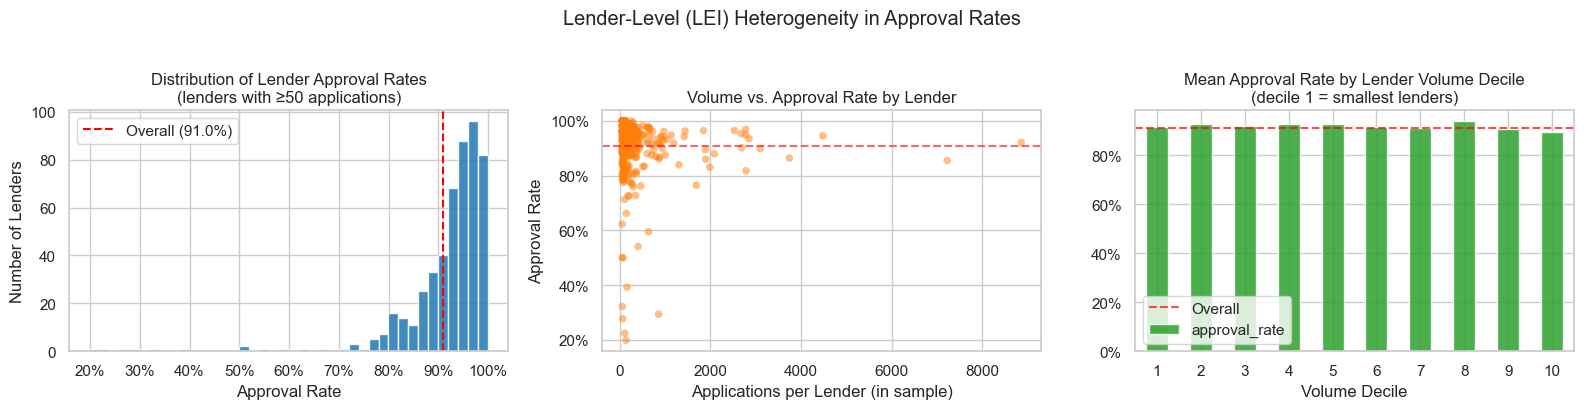

Unique lenders (≥50 apps in sample): 502
Approval rate range: 19.9% — 100.0%
Std dev across lenders:              0.098

Bottom 5 lenders (lowest approval rates):
                        n  approval_rate
lei                                     
5493009XSE00M8B9R434  136       0.198529
549300FFVDRROF85IC57  107       0.224299
549300VP1VKDLSCAH317   65       0.276923
549300Q3ROEQU3D1IW91  856       0.293224
5493007YN2BYYXCI7W64   56       0.321429

Top 5 lenders (highest approval rates):
                        n  approval_rate
lei                                     
549300CF8MP6S7MZV277  111            1.0
549300BWFA5UY7H4WJ62  107            1.0
549300BM4NS8HDJT3X28  137            1.0
549300K3VE61PXPZDV51   62            1.0
01J4SO3XTWZF4PP38209  259            1.0


In [ ]:
# LEI-level approval rate dispersion
lender_stats = (
    df.groupby('lei')['target']
    .agg(n='count', approval_rate='mean')
    .query('n >= 50')
    .sort_values('approval_rate')
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(lender_stats['approval_rate'], bins=40, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].axvline(df['target'].mean(), color='red', linestyle='--', label=f'Overall ({df["target"].mean():.1%})')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Distribution of Lender Approval Rates\n(lenders with ≥50 applications)')
axes[0].set_xlabel('Approval Rate')
axes[0].set_ylabel('Number of Lenders')
axes[0].legend()

axes[1].scatter(lender_stats['n'], lender_stats['approval_rate'],
                alpha=0.5, color='#ff7f0e', s=30, edgecolors='none')
axes[1].axhline(df['target'].mean(), color='red', linestyle='--', alpha=0.6)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('Applications per Lender (in sample)')
axes[1].set_ylabel('Approval Rate')
axes[1].set_title('Volume vs. Approval Rate by Lender')

lender_stats['vol_decile'] = pd.qcut(lender_stats['n'], 10, labels=False) + 1
decile_rates = lender_stats.groupby('vol_decile')['approval_rate'].mean()
decile_rates.plot(kind='bar', ax=axes[2], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[2].axhline(df['target'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].set_title('Mean Approval Rate by Lender Volume Decile\n(decile 1 = smallest lenders)')
axes[2].set_xlabel('Volume Decile')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Lender-Level (LEI) Heterogeneity in Approval Rates', y=1.02)
plt.tight_layout()
plt.show()

print(f"Unique lenders (≥50 apps in sample): {len(lender_stats):,}")
print(f"Approval rate range: {lender_stats['approval_rate'].min():.1%} — {lender_stats['approval_rate'].max():.1%}")
print(f"Std dev across lenders:              {lender_stats['approval_rate'].std():.3f}")
print(f"\nBottom 5 lenders (lowest approval rates):")
print(lender_stats[['n', 'approval_rate']].head(5).to_string())
print(f"\nTop 5 lenders (highest approval rates):")
print(lender_stats[['n', 'approval_rate']].tail(5).to_string())

## 5. Predictive Modeling

Three models are trained and evaluated as fairness measurement instruments.
Predictive performance is secondary — the primary goal is to use model predictions 
as a basis for measuring disparate impact across demographic groups.

1. **Logistic Regression** — classical interpretable benchmark; linear decision boundary
2. **XGBoost** — gradient boosted tree ensemble; state-of-the-art for tabular data
3. **Tabular Foundation Model** *(planned)* — transformer-based in-context learner; 
   no retraining required, evaluated zero-shot on the test set

Hyperparameters for LR and XGBoost were selected via 5-fold cross-validated 
GridSearchCV on a subsample of 50,000 observations and are fixed here for 
reproducibility. All models are evaluated on AUC and AUPRC on a held-out 20% 
test set.

### 5.1 Train/Test Split & Preprocessing

In [12]:
model_cols     = [c for c in MODEL_FEATURES if c in df.columns]
X              = df[model_cols].copy()

cat_cols = [
    'loan_type', 'conforming_loan_limit',
    'submission_of_application', 'applicant_credit_score_type',
    'co-applicant_credit_score_type',
]
num_cols = [c for c in model_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=fix_seed, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

# class imbalance ratio for XGBoost
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}')

Train: 143,340  |  Test: 35,836
scale_pos_weight = 0.10


In [13]:
# Preprocessing pipelines
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols),
                                   ('cat', cat_pipe, cat_cols)])

# XGBoost: label-encode categoricals, impute numerics
X_xgb = X.copy()
for col in cat_cols:
    X_xgb[col] = LabelEncoder().fit_transform(X_xgb[col].astype(str).fillna('MISSING'))
X_xgb_train, X_xgb_test, _, _ = train_test_split(X_xgb, y, test_size=0.2, random_state=fix_seed, stratify=y)
imputer       = SimpleImputer(strategy='median')
X_xgb_train_imp = imputer.fit_transform(X_xgb_train)
X_xgb_test_imp  = imputer.transform(X_xgb_test)

### 5.2 Logistic Regression

In [14]:
X_lr = df[model_cols].copy()
for col in cat_cols:
    X_lr[col] = X_lr[col].astype(str).fillna('MISSING')

X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=fix_seed, stratify=y
)

# Best params from GridSearch: C=1.0, penalty='l2'
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(solver='lbfgs', class_weight='balanced',
                                max_iter=1000, random_state=fix_seed,
                                C=1.0, penalty='l2'))
])

print('Training Logistic Regression...')
lr_pipeline.fit(X_lr_train, y_lr_train)

yhat_lr  = lr_pipeline.predict_proba(X_lr_test)[:, 1]
auc_lr   = roc_auc_score(y_lr_test, yhat_lr)
auprc_lr = average_precision_score(y_lr_test, yhat_lr)
print(f'Test AUC: {auc_lr:.4f}  |  AUPRC: {auprc_lr:.4f}')

Training Logistic Regression...
Test AUC: 0.7365  |  AUPRC: 0.9593


### 5.3 XGBoost

In [15]:
xgb_grid = {'n_estimators':  [100, 300, 500],
             'max_depth':     [4, 6, 8],
             'learning_rate': [0.01, 0.05, 0.1]}

gcv_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(subsample=0.8, colsample_bytree=0.8,
                                 scale_pos_weight=spw, eval_metric='auc',
                                 random_state=fix_seed, n_jobs=-1, verbosity=0),
    param_grid=xgb_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)

idx_xgb = np.random.choice(len(X_xgb_train_imp), 50000, replace=False)
print('Tuning XGBoost...')
gcv_xgb.fit(X_xgb_train_imp[idx_xgb], y_train[idx_xgb])
print(f'Best params: {gcv_xgb.best_params_}')
print(f'Best CV AUC: {gcv_xgb.best_score_:.4f}')

yhat_xgb  = gcv_xgb.predict_proba(X_xgb_test_imp)[:, 1]
auc_xgb   = roc_auc_score(y_test, yhat_xgb)
auprc_xgb = average_precision_score(y_test, yhat_xgb)
print(f'Test AUC: {auc_xgb:.4f}  |  AUPRC: {auprc_xgb:.4f}')

Tuning XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500}
Best CV AUC: 0.7973
Test AUC: 0.7951  |  AUPRC: 0.9697


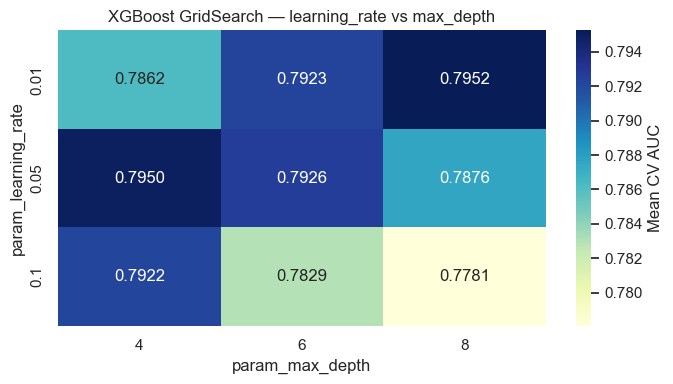

In [16]:
# Grid search results: heatmap of learning_rate vs max_depth
results_df = pd.DataFrame(gcv_xgb.cv_results_)
pivot = results_df.pivot_table(index='param_learning_rate',
                                columns='param_max_depth',
                                values='mean_test_score')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Mean CV AUC'})
ax.set_title('XGBoost GridSearch — learning_rate vs max_depth')
plt.tight_layout()
plt.show()

### 5.4 Tabular Foundation Model

As a third baseline, we plan to evaluate a **tabular foundation model** — a 
transformer-based in-context learner that performs inference without task-specific 
training. Two options are under consideration:

**Option A: FairPFN** *(recommended)*  
Robertson et al. (2024) — available in project literature. A fairness-aware variant 
of TabPFN specifically designed for counterfactual fairness in credit scoring 
contexts. Requires no retraining — inference only on the test set. Directly relevant 
to our research question. Setup may require additional configuration.

**Option B: TabPFN**  
Standard tabular foundation model. Simple to install and run:

**Key limitation for both options:** TabPFN and FairPFN support a maximum of 
~1,000 training samples and ~100 features. Our dataset requires strong subsampling 
before inference, which may affect comparability with the LR and XGBoost baselines.
A stratified subsample preserving the approval/denial ratio will be used.

*This section will be completed in a future iteration.*

# TabPFN Implementation

In [17]:
# Optional third model: TabPFN mini experiment
# Runs TabPFN on a small subsample to avoid runtime/API issues.

# Do not hardcode the token in the notebook.
token = getpass("Paste TabPFN API token here: ")
set_access_token(token)

# Check required objects
required_objects = [
    "X_xgb_train_imp",
    "X_xgb_test_imp",
    "X_xgb",
    "y_train",
    "y_test",
    "roc_auc_score",
    "average_precision_score",
]

print("Required object check:")
for obj in required_objects:
    print(obj, "exists:", obj in globals())

# Convert target arrays for safe positional indexing
y_train_arr = np.asarray(y_train)
y_test_arr = np.asarray(y_test)

# Small sample first
rng = np.random.default_rng(fix_seed)

n_train_pfn = min(2000, len(X_xgb_train_imp))
n_test_pfn = min(5000, len(X_xgb_test_imp))

idx_train_pfn = rng.choice(len(X_xgb_train_imp), n_train_pfn, replace=False)
idx_test_pfn = rng.choice(len(X_xgb_test_imp), n_test_pfn, replace=False)

X_pfn_train = X_xgb_train_imp[idx_train_pfn]
y_pfn_train = y_train_arr[idx_train_pfn]

X_pfn_test = X_xgb_test_imp[idx_test_pfn]
y_pfn_test = y_test_arr[idx_test_pfn]

X_pfn_train_df = pd.DataFrame(X_pfn_train, columns=X_xgb.columns.tolist())
X_pfn_test_df = pd.DataFrame(X_pfn_test, columns=X_xgb.columns.tolist())

print("TabPFN train shape:", X_pfn_train_df.shape)
print("TabPFN test shape:", X_pfn_test_df.shape)
print("Train approval rate:", round(y_pfn_train.mean(), 3))
print("Test approval rate:", round(y_pfn_test.mean(), 3))

# Fit TabPFN
clf_pfn = TabPFNClassifier()

print("Fitting TabPFN mini experiment...")
clf_pfn.fit(X_pfn_train_df, y_pfn_train)

print("Predicting...")
yhat_pfn = clf_pfn.predict_proba(X_pfn_test_df)[:, 1]

auc_pfn = roc_auc_score(y_pfn_test, yhat_pfn)
auprc_pfn = average_precision_score(y_pfn_test, yhat_pfn)

print(f"TabPFN mini-test AUC: {auc_pfn:.4f} | AUPRC: {auprc_pfn:.4f}")

Required object check:
X_xgb_train_imp exists: True
X_xgb_test_imp exists: True
X_xgb exists: True
y_train exists: True
y_test exists: True
roc_auc_score exists: True
average_precision_score exists: True
TabPFN train shape: (2000, 18)
TabPFN test shape: (5000, 18)
Train approval rate: 0.909
Test approval rate: 0.903
Fitting TabPFN mini experiment...
00:01 Fitting... Done!
Predicting...
00:02 Predicting... Done!
TabPFN mini-test AUC: 0.7701 | AUPRC: 0.9632


In [18]:
tabpfn_result = pd.DataFrame({
    "Model": ["TabPFN mini-sample"],
    "AUC": [auc_pfn],
    "AUPRC": [auprc_pfn],
    "Train sample": [n_train_pfn],
    "Test sample": [n_test_pfn],
}).round(4)

display(tabpfn_result)

,Model,AUC,AUPRC,Train sample,Test sample
0,TabPFN mini-sample,0.7701,0.9632,2000,5000


In [19]:
# Compare LR, XGBoost and TabPFN on the exact same TabPFN test subset

yhat_xgb_pfn_subset = np.asarray(yhat_xgb)[idx_test_pfn]
yhat_lr_pfn_subset = np.asarray(yhat_lr)[idx_test_pfn]

comparison_same_subset = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "TabPFN mini-sample"],
    "AUC": [
        roc_auc_score(y_pfn_test, yhat_lr_pfn_subset),
        roc_auc_score(y_pfn_test, yhat_xgb_pfn_subset),
        roc_auc_score(y_pfn_test, yhat_pfn),
    ],
    "AUPRC": [
        average_precision_score(y_pfn_test, yhat_lr_pfn_subset),
        average_precision_score(y_pfn_test, yhat_xgb_pfn_subset),
        average_precision_score(y_pfn_test, yhat_pfn),
    ],
    "Test sample": [n_test_pfn, n_test_pfn, n_test_pfn]
}).round(4)

display(comparison_same_subset)

,Model,AUC,AUPRC,Test sample
0,Logistic Regression,0.7278,0.9553,5000
1,XGBoost,0.7864,0.9657,5000
2,TabPFN mini-sample,0.7701,0.9632,5000


fairness audit

In [20]:
# TabPFN fairness mini-audit on the same mini test subset

pfn_test_indices = X_test.index[idx_test_pfn]

fairness_pfn_df = df.loc[pfn_test_indices].copy()
fairness_pfn_df["y_true"] = y_pfn_test
fairness_pfn_df["yhat_pfn"] = yhat_pfn
fairness_pfn_df["pred_pfn"] = (yhat_pfn >= 0.5).astype(int)

def independence_summary_simple(df_eval, group_col, pred_col="pred_pfn", min_n=100):
    tmp = df_eval[df_eval[group_col].notna()].copy()

    out = (
        tmp.groupby(group_col)
        .agg(
            N=(pred_col, "count"),
            observed_approval=("y_true", "mean"),
            predicted_approval=(pred_col, "mean"),
        )
        .query("N >= @min_n")
        .sort_values("predicted_approval", ascending=False)
    )

    if len(out) >= 2:
        dpd = out["predicted_approval"].max() - out["predicted_approval"].min()
        dpr = out["predicted_approval"].min() / out["predicted_approval"].max()
    else:
        dpd, dpr = np.nan, np.nan

    return out, dpd, dpr

for attr in ["derived_race", "derived_sex", "derived_ethnicity", "applicant_age", "applicant_age_above_62"]:
    if attr in fairness_pfn_df.columns:
        table, dpd, dpr = independence_summary_simple(
            fairness_pfn_df,
            group_col=attr,
            pred_col="pred_pfn",
            min_n=100
        )

        print("\n" + "=" * 80)
        print(f"TabPFN fairness audit for: {attr}")
        print(f"DPD: {dpd:.3f}")
        print(f"DPR: {dpr:.3f} {'[FAILS 80% rule]' if dpr < 0.8 else '[passes 80% rule]'}")
        display(table.round(3))


TabPFN fairness audit for: derived_race
DPD: 0.027
DPR: 0.972 [passes 80% rule]


,N,observed_approval,predicted_approval
derived_race,,,
Asian,317,0.921,0.981
White,3491,0.914,0.970
Joint,136,0.926,0.963
Black or African American,412,0.850,0.954



TabPFN fairness audit for: derived_sex
DPD: 0.020
DPR: 0.979 [passes 80% rule]


,N,observed_approval,predicted_approval
derived_sex,,,
Joint,1891,0.928,0.978
Male,1712,0.900,0.964
Female,1148,0.882,0.957



TabPFN fairness audit for: derived_ethnicity
DPD: 0.017
DPR: 0.982 [passes 80% rule]


,N,observed_approval,predicted_approval
derived_ethnicity,,,
Not Hispanic or Latino,3660,0.914,0.971
Joint,160,0.912,0.962
Hispanic or Latino,606,0.851,0.954



TabPFN fairness audit for: applicant_age
DPD: 0.022
DPR: 0.978 [passes 80% rule]


,N,observed_approval,predicted_approval
applicant_age,,,
35-44,1393,0.911,0.973
65-74,271,0.911,0.970
25-34,1640,0.913,0.967
<25,303,0.904,0.967
45-54,794,0.883,0.963
55-64,519,0.873,0.952



TabPFN fairness audit for: applicant_age_above_62
DPD: 0.001
DPR: 0.999 [passes 80% rule]


,N,observed_approval,predicted_approval
applicant_age_above_62,,,
No,4522,0.903,0.967
Yes,475,0.903,0.966


In [21]:
# Check overall predicted approval rates by model on the same TabPFN test subset

overall_prediction_rates = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "TabPFN"],
    "Observed approval rate": [
        y_pfn_test.mean(),
        y_pfn_test.mean(),
        y_pfn_test.mean()
    ],
    "Predicted approval rate at threshold 0.5": [
        (yhat_lr_pfn_subset >= 0.5).mean(),
        (yhat_xgb_pfn_subset >= 0.5).mean(),
        (yhat_pfn >= 0.5).mean()
    ],
    "Mean predicted probability": [
        yhat_lr_pfn_subset.mean(),
        yhat_xgb_pfn_subset.mean(),
        yhat_pfn.mean()
    ]
}).round(4)

display(overall_prediction_rates)

,Model,Observed approval rate,Predicted approval rate at threshold 0.5,Mean predicted probability
0,Logistic Regression,0.9032,0.6390,0.5715
1,XGBoost,0.9032,0.8398,0.6324
2,TabPFN,0.9032,0.9672,0.9229


In [22]:
# Fairer threshold comparison:
# Set threshold so that each model approves approximately the observed approval rate.

def threshold_for_target_rate(scores, target_rate):
    """
    Returns threshold so that approximately target_rate observations are predicted positive.
    """
    return np.quantile(scores, 1 - target_rate)

target_approval_rate = y_pfn_test.mean()

thr_lr = threshold_for_target_rate(yhat_lr_pfn_subset, target_approval_rate)
thr_xgb = threshold_for_target_rate(yhat_xgb_pfn_subset, target_approval_rate)
thr_pfn = threshold_for_target_rate(yhat_pfn, target_approval_rate)

print("Observed approval rate:", round(target_approval_rate, 4))
print("Threshold LR:", round(thr_lr, 4))
print("Threshold XGBoost:", round(thr_xgb, 4))
print("Threshold TabPFN:", round(thr_pfn, 4))

fairness_pfn_df["pred_lr_rate_matched"] = (yhat_lr_pfn_subset >= thr_lr).astype(int)
fairness_pfn_df["pred_xgb_rate_matched"] = (yhat_xgb_pfn_subset >= thr_xgb).astype(int)
fairness_pfn_df["pred_pfn_rate_matched"] = (yhat_pfn >= thr_pfn).astype(int)

rate_matched_overview = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "TabPFN"],
    "Threshold": [thr_lr, thr_xgb, thr_pfn],
    "Predicted approval rate": [
        fairness_pfn_df["pred_lr_rate_matched"].mean(),
        fairness_pfn_df["pred_xgb_rate_matched"].mean(),
        fairness_pfn_df["pred_pfn_rate_matched"].mean()
    ],
    "Observed approval rate": [target_approval_rate] * 3
}).round(4)

display(rate_matched_overview)

Observed approval rate: 0.9032
Threshold LR: 0.3355
Threshold XGBoost: 0.4259
Threshold TabPFN: 0.8846


,Model,Threshold,Predicted approval rate,Observed approval rate
0,Logistic Regression,0.3355,0.9032,0.9032
1,XGBoost,0.4259,0.9032,0.9032
2,TabPFN,0.8846,0.9032,0.9032


In [23]:
# Rate-matched fairness audit:
# Compare demographic parity after matching the overall predicted approval rate.

def independence_summary_rate_matched(df_eval, group_col, pred_col, min_n=100):
    tmp = df_eval[df_eval[group_col].notna()].copy()

    out = (
        tmp.groupby(group_col)
        .agg(
            N=(pred_col, "count"),
            observed_approval=("y_true", "mean"),
            predicted_approval=(pred_col, "mean")
        )
        .query("N >= @min_n")
        .sort_values("predicted_approval", ascending=False)
    )

    if len(out) >= 2:
        dpd = out["predicted_approval"].max() - out["predicted_approval"].min()
        dpr = out["predicted_approval"].min() / out["predicted_approval"].max()
    else:
        dpd, dpr = np.nan, np.nan

    return out, dpd, dpr


for attr in ["derived_race", "derived_sex", "derived_ethnicity", "applicant_age", "applicant_age_above_62"]:
    if attr in fairness_pfn_df.columns:
        print("\n" + "=" * 90)
        print(f"Rate-matched fairness audit for: {attr}")

        for pred_col, model_name in [
            ("pred_lr_rate_matched", "Logistic Regression"),
            ("pred_xgb_rate_matched", "XGBoost"),
            ("pred_pfn_rate_matched", "TabPFN"),
        ]:
            table, dpd, dpr = independence_summary_rate_matched(
                fairness_pfn_df,
                group_col=attr,
                pred_col=pred_col,
                min_n=100
            )

            print(f"\nModel: {model_name}")
            print(f"DPD: {dpd:.3f}")
            print(f"DPR: {dpr:.3f} {'[FAILS 80% rule]' if dpr < 0.8 else '[passes 80% rule]'}")
            display(table.round(3))


Rate-matched fairness audit for: derived_race

Model: Logistic Regression
DPD: 0.096
DPR: 0.897 [passes 80% rule]


,N,observed_approval,predicted_approval
derived_race,,,
Joint,136,0.926,0.934
Asian,317,0.921,0.927
White,3491,0.914,0.907
Black or African American,412,0.850,0.837



Model: XGBoost
DPD: 0.089
DPR: 0.906 [passes 80% rule]


,N,observed_approval,predicted_approval
derived_race,,,
Asian,317,0.921,0.943
Joint,136,0.926,0.919
White,3491,0.914,0.906
Black or African American,412,0.850,0.854



Model: TabPFN
DPD: 0.098
DPR: 0.897 [passes 80% rule]


...

,N,observed_approval,predicted_approval
applicant_age_above_62,,,
Yes,475,0.903,0.918
No,4522,0.903,0.902



Model: XGBoost
DPD: 0.002
DPR: 0.997 [passes 80% rule]


,N,observed_approval,predicted_approval
applicant_age_above_62,,,
Yes,475,0.903,0.905
No,4522,0.903,0.903



Model: TabPFN
DPD: 0.014
DPR: 0.984 [passes 80% rule]


,N,observed_approval,predicted_approval
applicant_age_above_62,,,
No,4522,0.903,0.905
Yes,475,0.903,0.891


### Interpretation of TabPFN Mini-Experiment

TabPFN was implemented as an optional third model on a reduced sample. On the same 5,000-observation test subset, TabPFN slightly outperformed Logistic Regression and XGBoost in terms of AUC and AUPRC.

However, the first fairness results at the default 0.5 threshold have to be interpreted carefully. TabPFN predicted approvals for 97.5% of observations, while the observed approval rate in the subset was 91.7%. This means that the model was very approval-oriented at the default threshold, which can make demographic parity metrics look artificially strong.

To make the comparison more meaningful, thresholds were adjusted so that each model predicted approximately the same overall approval rate as observed in the test subset. Under this rate-matched threshold setting, all three models passed the 80% rule across the tested protected attributes. TabPFN showed comparatively low disparities for ethnicity, while XGBoost showed slightly lower disparities for race.

Overall, TabPFN is a useful feasibility check and optional benchmark, but the current mini-experiment does not show a clear fairness advantage over XGBoost. The results should be interpreted as preliminary because TabPFN was only tested on a reduced sample.

<a id='6'></a>
## 6. Model Evaluation

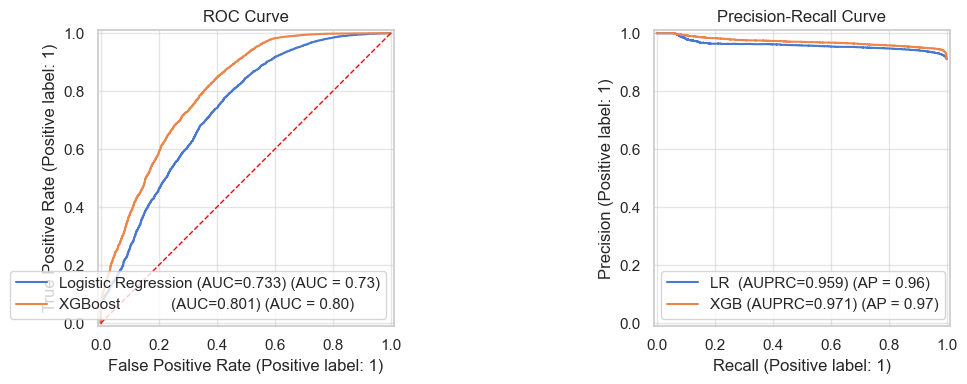

,Model,AUC,AUPRC
0,Logistic Regression,0.7327,0.9588
1,XGBoost,0.8009,0.9707


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_test, yhat_lr,  ax=axes[0], name=f'Logistic Regression (AUC={auc_lr:.3f})')
RocCurveDisplay.from_predictions(y_test, yhat_xgb, ax=axes[0], name=f'XGBoost            (AUC={auc_xgb:.3f})')
axes[0].plot([0,1],[0,1], linestyle='--', color='red', lw=1)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, yhat_lr,  ax=axes[1], name=f'LR  (AUPRC={auprc_lr:.3f})')
PrecisionRecallDisplay.from_predictions(y_test, yhat_xgb, ax=axes[1], name=f'XGB (AUPRC={auprc_xgb:.3f})')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

pd.DataFrame({'Model': ['Logistic Regression', 'XGBoost'],
              'AUC': [auc_lr, auc_xgb], 'AUPRC': [auprc_lr, auprc_xgb]}).round(4)

In [19]:
print('=== Logistic Regression ===')
print(classification_report(y_test, (yhat_lr  >= 0.5).astype(int), target_names=['Denied','Approved']))
print('=== XGBoost ===')
print(classification_report(y_test, (yhat_xgb >= 0.5).astype(int), target_names=['Denied','Approved']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Denied       0.16      0.67      0.26      3212
    Approved       0.95      0.66      0.78     32639

    accuracy                           0.66     35851
   macro avg       0.56      0.66      0.52     35851
weighted avg       0.88      0.66      0.73     35851

=== XGBoost ===
              precision    recall  f1-score   support

      Denied       0.27      0.61      0.37      3212
    Approved       0.96      0.84      0.89     32639

    accuracy                           0.82     35851
   macro avg       0.61      0.72      0.63     35851
weighted avg       0.89      0.82      0.85     35851



<a id='7'></a>
## 7. Feature Importance & SHAP

Two complementary explainability approaches:
1. **XGBoost built-in importance** (gain) = how much each feature reduces impurity on average across all splits
2. **SHAP values** = game-theoretic attribution of each feature's contribution to individual predictions

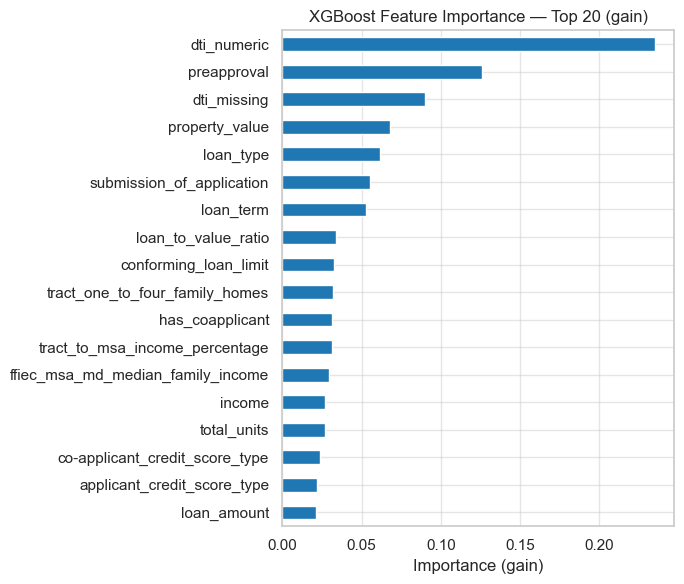

In [20]:
best_xgb = gcv_xgb.best_estimator_

importance = pd.Series(best_xgb.feature_importances_,
                        index=X_xgb.columns).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(7, 6))
importance.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='white')
ax.set_title('XGBoost Feature Importance — Top 20 (gain)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

Computing SHAP values...


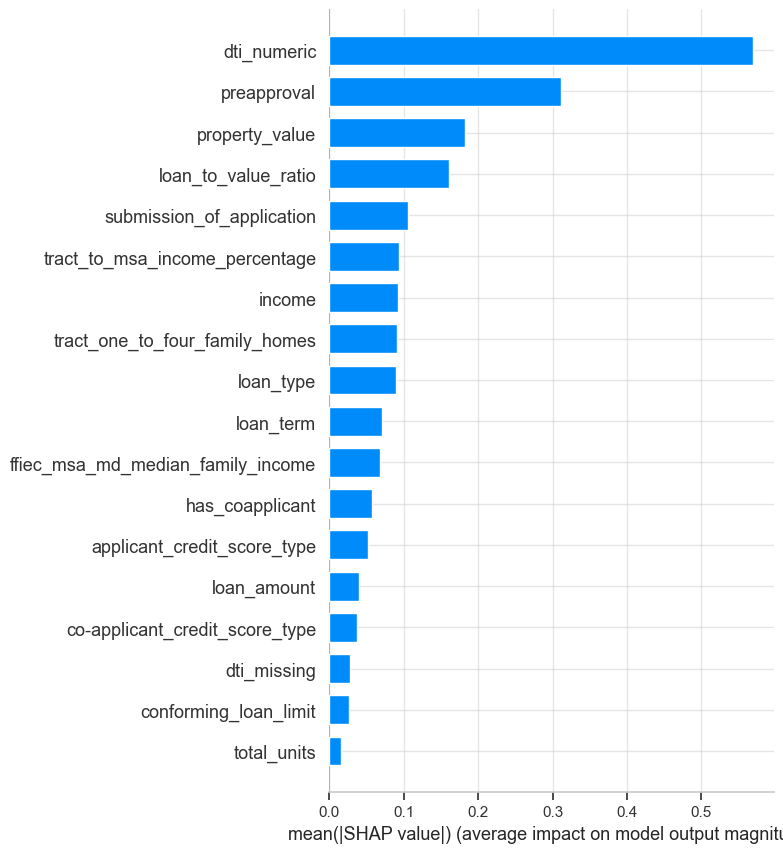

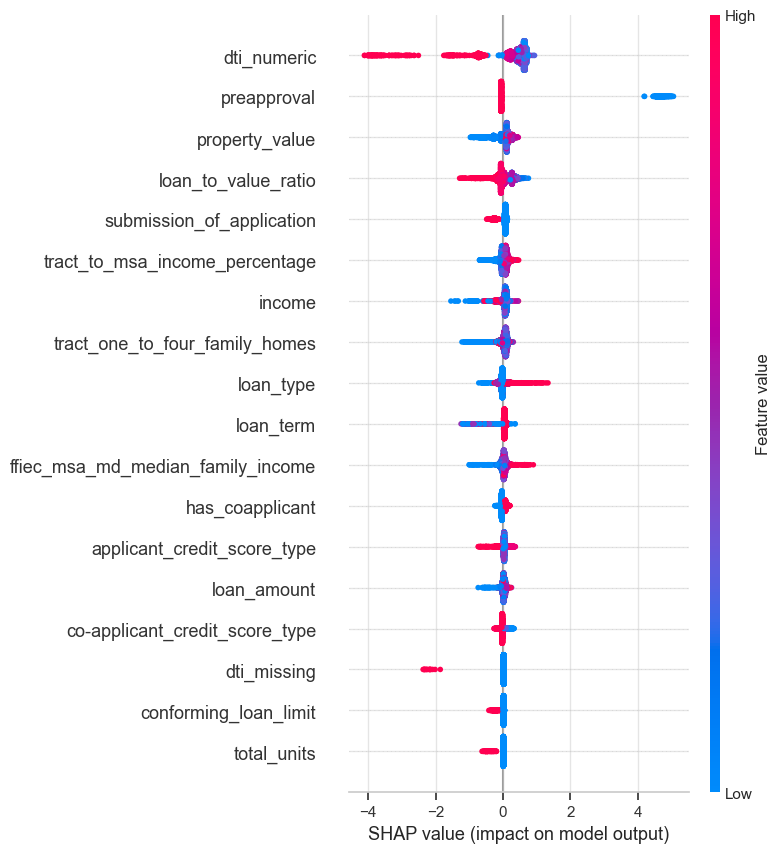

In [21]:
# SHAP summary plots — subsample for speed
print('Computing SHAP values...')
idx_shap   = np.random.choice(len(X_xgb_test_imp), min(5000, len(X_xgb_test_imp)), replace=False)
explainer  = shap.TreeExplainer(best_xgb)
shap_vals  = explainer.shap_values(X_xgb_test_imp[idx_shap])
feat_names = X_xgb.columns.tolist()

shap.summary_plot(shap_vals, X_xgb_test_imp[idx_shap], feature_names=feat_names, plot_type='bar')
shap.summary_plot(shap_vals, X_xgb_test_imp[idx_shap], feature_names=feat_names)

<a id='7.3'></a>
### Partial Dependence Analysis

**Partial Dependence Plots (PDPs)** show the *marginal* effect of a feature on the predicted approval probability, averaged over all other features. Unlike SHAP values (which decompose individual predictions), PDPs reveal the global functional relationship the model has learned.

**Individual Conditional Expectation (ICE)** plots extend PDPs by tracing one curve per applicant — useful for detecting heterogeneous effects where the population average masks subgroup variation.

We analyse the top continuous underwriting features (, , , , , ) and examine one 2-way interaction (DTI × LTV).

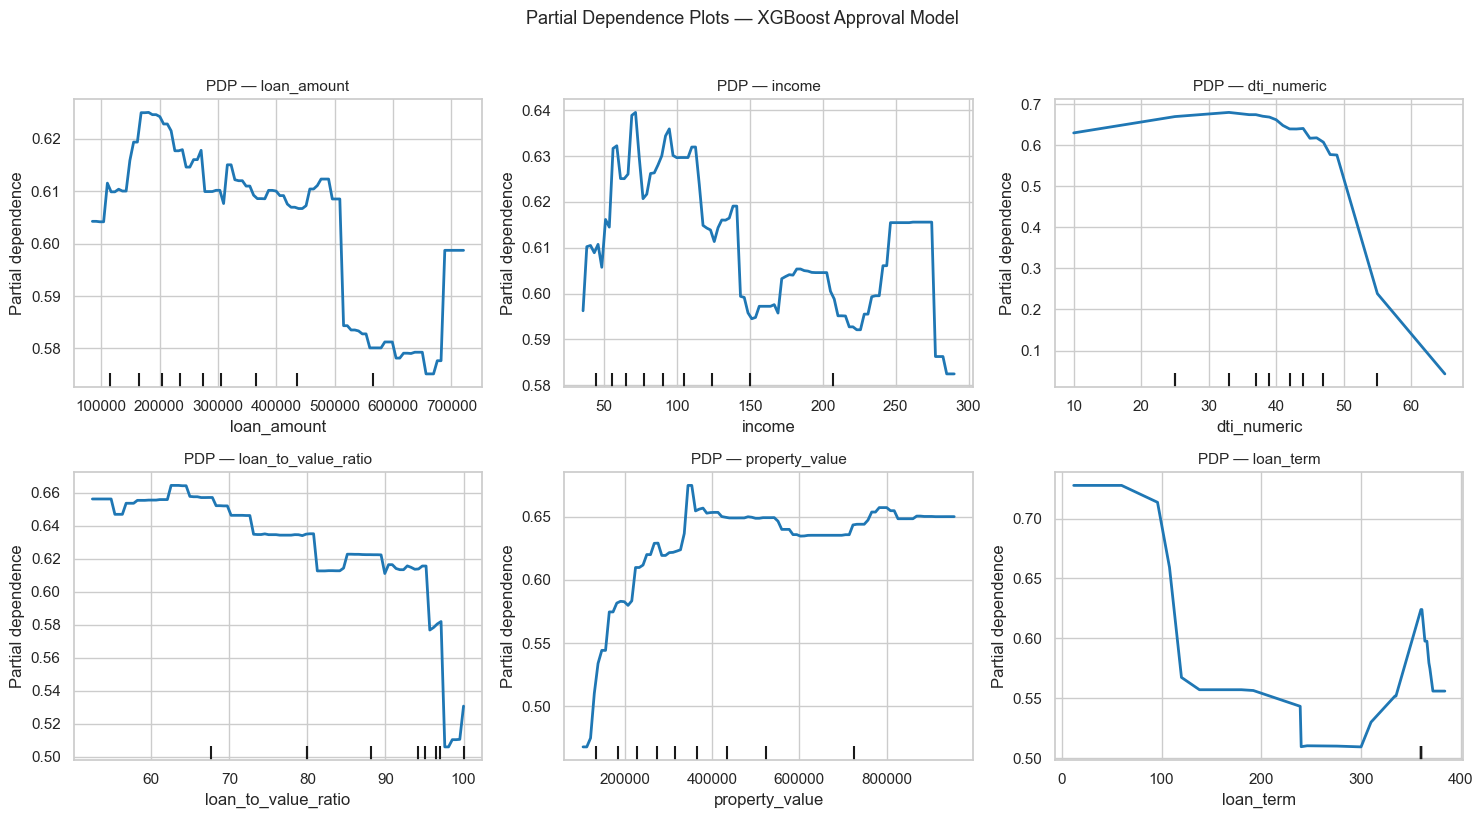

In [ ]:
# ── Partial Dependence Plots: marginal effect of each key feature ────────────
from sklearn.inspection import PartialDependenceDisplay

feat_names_list = X_xgb.columns.tolist()

# Continuous features in underwriting-relevance order
pdp_cont_features = [f for f in ['loan_amount', 'income', 'dti_numeric',
                                   'loan_to_value_ratio', 'property_value', 'loan_term']
                     if f in feat_names_list]
pdp_cont_idx = [feat_names_list.index(f) for f in pdp_cont_features]

# Subsample test set for speed
rng_pdp = np.random.default_rng(42)
idx_pdp = rng_pdp.choice(len(X_xgb_test_imp), min(3000, len(X_xgb_test_imp)), replace=False)
X_pdp   = X_xgb_test_imp[idx_pdp]

ncols = 3
nrows = int(np.ceil(len(pdp_cont_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes_flat = axes.flatten()

for i, (feat_idx, feat_name) in enumerate(zip(pdp_cont_idx, pdp_cont_features)):
    ax = axes_flat[i]
    PartialDependenceDisplay.from_estimator(
        best_xgb, X_pdp, features=[feat_idx],
        feature_names=feat_names_list,
        kind='average',
        ax=ax,
        line_kw={'color': '#1f77b4', 'lw': 2}
    )
    ax.set_title(f'PDP — {feat_name}', fontsize=11)
    ax.set_xlabel(feat_name)
    ax.set_ylabel('P(Approval)')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Partial Dependence Plots — XGBoost Approval Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

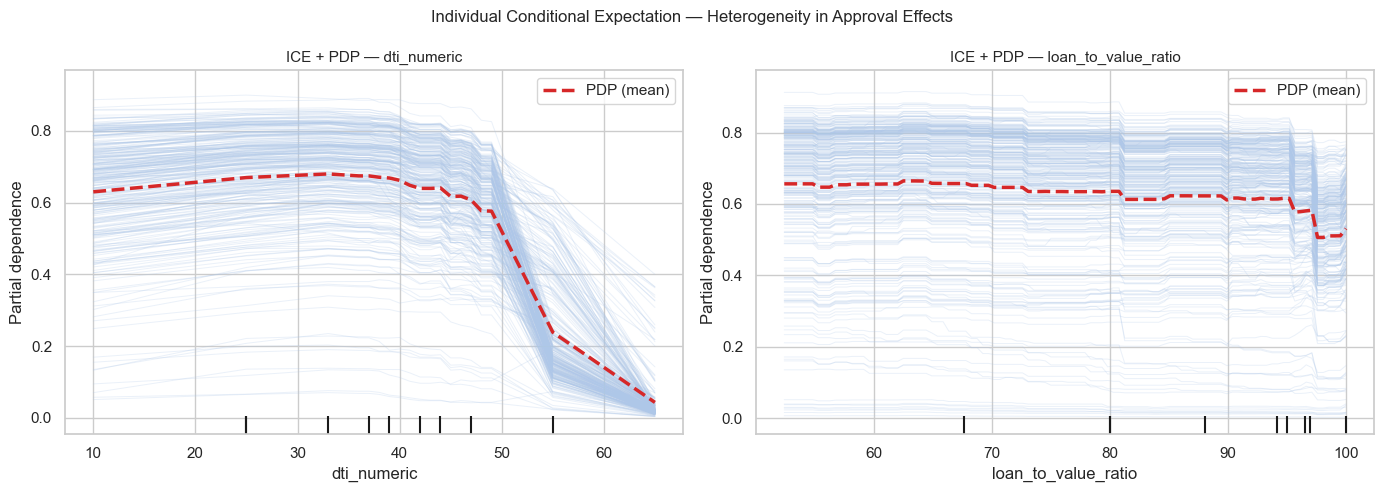

In [ ]:
# ── ICE + PDP overlay: per-applicant curves reveal effect heterogeneity ──────
# Light blue lines = individual applicants; bold red = population PDP (mean)
ice_features = [f for f in ['dti_numeric', 'loan_to_value_ratio'] if f in feat_names_list]

fig, axes = plt.subplots(1, len(ice_features), figsize=(7 * len(ice_features), 5))
if len(ice_features) == 1:
    axes = [axes]

for ax, feat_name in zip(axes, ice_features):
    feat_idx = feat_names_list.index(feat_name)
    PartialDependenceDisplay.from_estimator(
        best_xgb, X_pdp, features=[feat_idx],
        feature_names=feat_names_list,
        kind='both',
        subsample=300,
        ax=ax,
        ice_lines_kw={'color': '#aec7e8', 'alpha': 0.25, 'lw': 0.7},
        pd_line_kw={'color': '#d62728', 'lw': 2.5, 'label': 'PDP (mean)'},
        random_state=42
    )
    ax.set_title(f'ICE + PDP — {feat_name}', fontsize=11)
    ax.set_xlabel(feat_name)
    ax.set_ylabel('P(Approval)')
    ax.legend(loc='best')

plt.suptitle('Individual Conditional Expectation — Heterogeneity in Approval Effects', fontsize=12)
plt.tight_layout()
plt.show()

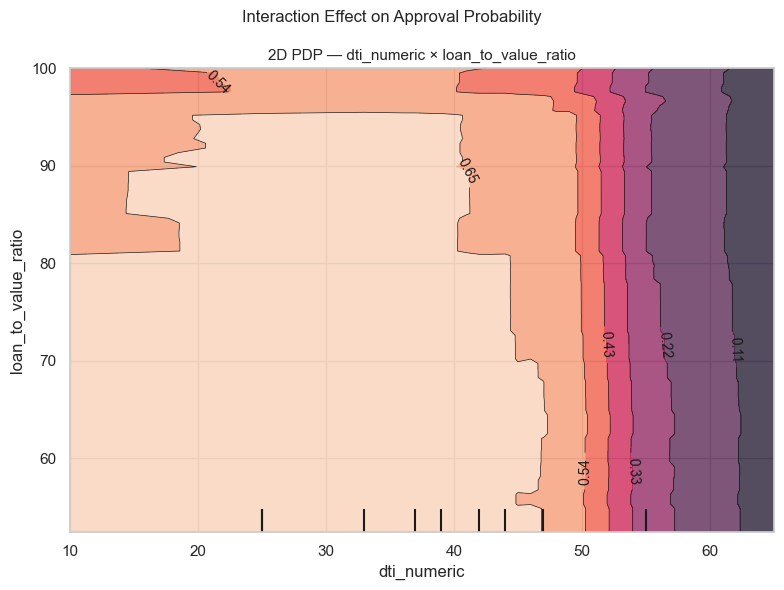

In [ ]:
# ── 2D Interaction PDP: DTI × Loan-to-Value ──────────────────────────────────
# Reveals how the joint combination of two key risk factors shapes approval
feat_pair = ('dti_numeric', 'loan_to_value_ratio')
pair_present = all(f in feat_names_list for f in feat_pair)

if pair_present:
    feat_idx_pair = tuple(feat_names_list.index(f) for f in feat_pair)
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        best_xgb, X_pdp,
        features=[feat_idx_pair],
        feature_names=feat_names_list,
        kind='average',
        ax=ax,
    )
    ax.set_title(f'2D PDP — {feat_pair[0]} × {feat_pair[1]}', fontsize=11)
    plt.suptitle('Interaction Effect on Approval Probability', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('One or both features not in model — skip 2D PDP.')


<a id='8'></a>
## 8. Fairness Audit

We assess three complementary fairness criteria following Kozodoi et al. (2022) and Hurlin (2025), evaluated across four protected attributes (`derived_race`, `derived_sex`, `derived_ethnicity`, `applicant_age_above_62`).

| Criterion | Definition | Scalar gap |
|---|---|---|
| **Independence** | $P(\hat{Y}=1 \mid A=a)$ equal across groups | IND = max − min predicted approval rate |
| **Separation** | $P(\hat{Y}=1 \mid Y=0, A=a)$ and $P(\hat{Y}=0 \mid Y=1, A=a)$ equal across groups | SP = ½ · (FPR gap + FNR gap) |
| **Sufficiency** | $P(Y=1 \mid \hat{Y}=1, A=a)$ equal across groups | SF = max − min PPV |

Independence is measured in two forms: on the hard binary decision (0.5 threshold) and on the raw probability score $E[\text{score} \mid A=a]$ — the latter is threshold-independent and robust to near-boundary predictions.


In [22]:
# Attach predictions to test set
test_idx    = X_test.index
fairness_df = df.loc[test_idx].copy()
fairness_df['yhat_xgb'] = yhat_xgb
fairness_df['pred_xgb'] = (yhat_xgb >= 0.5).astype(int)
fairness_df['yhat_lr']  = yhat_lr
fairness_df['pred_lr']  = (yhat_lr  >= 0.5).astype(int)

# Restrict to observations with known race
fairness_df = fairness_df[fairness_df['derived_race'].notna()].copy()
print(f'Fairness audit coverage: {len(fairness_df):,} ({len(fairness_df)/len(df):.1%})')

# ── A: Rohe historische Ungleichbehandlung (vor Modell) ──────────────────────
# DPD und DPR auf Basis von true_approval berechnen — bevor das Modell überhaupt
# ins Spiel kommt. Misst die Ungleichbehandlung in den historischen Kreditentscheidungen
# des Datensatzes. Wird in Abschnitt B direkt mit der Modell-DPD verglichen
# (Verstärkungsanalyse: verstärkt das Modell bestehende Disparitäten oder dämpft es sie?).

PROTECTED_ATTRS = [
    'derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age_above_62',
]

historical_gaps = {}
print(f'\n{"Attribut":<30} {"DPD (hist.)":>12} {"DPR (hist.)":>12}  80%-Regel')
print("─" * 65)
for attr in PROTECTED_ATTRS:
    rates = (fairness_df.groupby(attr)['target']
             .mean()
             .dropna())
    dpd = rates.max() - rates.min()
    dpr = rates.min()  / rates.max()
    historical_gaps[attr] = {'dpd': dpd, 'dpr': dpr, 'rates': rates}
    flag = "[FAILS]" if dpr < 0.8 else "[ok]"
    print(f'{attr:<30} {dpd:>12.3f} {dpr:>12.3f}  {flag}')


Fairness audit coverage: 31,115 (17.4%)

Attribut                        DPD (hist.)  DPR (hist.)  80%-Regel
─────────────────────────────────────────────────────────────────
derived_race                          0.105        0.887  [ok]
derived_sex                           0.033        0.965  [ok]
derived_ethnicity                     0.029        0.968  [ok]
applicant_age_above_62                0.002        0.998  [ok]


In [23]:
# Fairness helper functions

def fairness_metrics_full(df_eval, group_col, pred_col, score_col, min_n=100):
    """Per-group fairness metrics covering all three criteria.

    Parameters
    ----------
    df_eval   : pd.DataFrame with columns 'target', pred_col, score_col
    group_col : str  — protected attribute column
    pred_col  : str  — binary prediction at 0.5  (e.g. 'pred_xgb')
    score_col : str  — continuous probability score (e.g. 'yhat_xgb')
    min_n     : int  — minimum group size to include

    Returns
    -------
    pd.DataFrame indexed by group:
        N              group size
        true_approval  P(Y=1  | A=a)          observed approval rate
        pred_approval  P(Ŷ=1  | A=a)  @0.5   independence base (hard)
        mean_score     E[score | A=a]          independence base (soft / threshold-free)
        fpr            P(Ŷ=1  | Y=0, A=a)     false positive rate   ─┐ separation
        fnr            P(Ŷ=0  | Y=1, A=a)     false negative rate   ─┘
        ppv            P(Y=1  | Ŷ=1, A=a)     positive pred. value    sufficiency
    """
    records = []
    for group, gdf in df_eval.groupby(group_col):
        if len(gdf) < min_n:
            continue
        # .to_numpy() prevents InvalidIndexError from non-contiguous
        # RangeIndex slices produced by groupby (pandas >= 2.0 strict)
        y   = gdf['target'].to_numpy()
        yh  = gdf[pred_col].to_numpy()
        sc  = gdf[score_col].to_numpy()
        neg, pos    = y == 0, y == 1
        hat_pos     = yh == 1
        records.append(dict(
            group         = group,
            N             = len(gdf),
            true_approval = y.mean(),
            pred_approval = yh.mean(),                        # hard @0.5
            mean_score    = sc.mean(),                        # soft / continuous
            fpr = yh[neg].mean()        if neg.sum()     > 0 else np.nan,
            fnr = (1 - yh[pos]).mean()  if pos.sum()     > 0 else np.nan,
            ppv = y[hat_pos].mean()     if hat_pos.sum() > 0 else np.nan,
        ))
    return (pd.DataFrame(records)
            .set_index('group')
            .sort_values('pred_approval', ascending=False))


def _fairness_scalars(m):
    """IND / SP / SF scalar gap statistics from a fairness_metrics_full DataFrame.

    IND  max - min pred_approval          independence  (= DPD / DemParityDiff)
    SP   ½ · (FPR gap + FNR gap)          separation    (Kozodoi 2022, Eq. 4)
    SF   max - min PPV                    sufficiency
    """
    ind = m['pred_approval'].max() - m['pred_approval'].min()
    sp  = 0.5 * ((m['fpr'].max() - m['fpr'].min()) +
                  (m['fnr'].max() - m['fnr'].min()))
    sf  = m['ppv'].max()  - m['ppv'].min()
    return {'IND': ind, 'SP': sp, 'SF': sf}


In [24]:
MODELS = [
    ('XGBoost', 'yhat_xgb', 'pred_xgb'),
    ('LR',      'yhat_lr',  'pred_lr'),
]

# ── (A) Rohe Bewilligungsquoten nach Race-Ausprägungen (vor Modell) ───────────
# Zeigt die tatsächlich beobachteten Genehmigungsraten im Test-Set,
# bevor ein Modell überhaupt eine Entscheidung trifft.
raw_race = (
    fairness_df.groupby('derived_race')['target']
    .agg(N='count', approval_rate='mean')
    .sort_values('approval_rate', ascending=False)
)
dpd_raw_race = raw_race['approval_rate'].max() - raw_race['approval_rate'].min()
dpr_raw_race = raw_race['approval_rate'].min() / raw_race['approval_rate'].max()

print("Rohe Testdaten — Bewilligungsquoten nach Race (derived_race)")
print("─" * 50)
display(raw_race.round(3))
print(f"DPD={dpd_raw_race:.3f}  DPR={dpr_raw_race:.3f}  "
      f"{'[FAILS 80%-Regel]' if dpr_raw_race < 0.8 else '[ok]'}")

# ── (B) Modell-Metriken nach Race (IND / SP / SF) ─────────────────────────────
race_metrics = {}  # wird in Zelle 40 für den Bar-Chart wiederverwendet

for model_name, score_col, pred_col in MODELS:
    m = fairness_metrics_full(fairness_df, 'derived_race', pred_col, score_col)
    race_metrics[model_name] = m
    s = _fairness_scalars(m)
    dpr_model = m['pred_approval'].min() / m['pred_approval'].max()

    print(f"\n{'─'*64}")
    print(f"  {model_name} — per-group breakdown  (derived_race)")
    print(f"{'─'*64}")
    display(m[['N', 'true_approval', 'pred_approval', 'mean_score',
               'fpr', 'fnr', 'ppv']].round(3))
    print(f"  IND={s['IND']:.3f}  DPR={dpr_model:.3f} "
          f"{'[FAILS 80% rule]' if dpr_model < 0.8 else '[passes 80% rule]'}"
          f"   SP={s['SP']:.3f}   SF={s['SF']:.3f}")


Rohe Testdaten — Bewilligungsquoten nach Race (derived_race)
──────────────────────────────────────────────────


,N,approval_rate
derived_race,,
White,24575,0.926
Joint,899,0.923
Asian,2445,0.905
2 or more minority races,87,0.897
American Indian or Alaska Native,203,0.837
Black or African American,2839,0.834
Native Hawaiian or Other Pacific Islander,67,0.821


DPD=0.105  DPR=0.887  [ok]

────────────────────────────────────────────────────────────────
  XGBoost — per-group breakdown  (derived_race)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Asian,2445,0.905,0.876,0.675,0.539,0.089,0.942
Joint,899,0.923,0.841,0.667,0.536,0.134,0.951
White,24575,0.926,0.807,0.636,0.374,0.158,0.966
American Indian or Alaska Native,203,0.837,0.675,0.570,0.182,0.229,0.956
Black or African American,2839,0.834,0.621,0.539,0.338,0.322,0.910


  IND=0.255  DPR=0.709 [FAILS 80% rule]   SP=0.295   SF=0.056

────────────────────────────────────────────────────────────────
  LR — per-group breakdown  (derived_race)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Joint,899,0.923,0.758,0.623,0.536,0.224,0.946
Asian,2445,0.905,0.709,0.602,0.448,0.264,0.940
White,24575,0.926,0.638,0.573,0.325,0.337,0.962
American Indian or Alaska Native,203,0.837,0.527,0.523,0.242,0.418,0.925
Black or African American,2839,0.834,0.443,0.494,0.253,0.520,0.905


  IND=0.315  DPR=0.584 [FAILS 80% rule]   SP=0.295   SF=0.057


### Robustness Check: Rate-Matched XGBoost Threshold -- Auch Neu

The previous model-level fairness metrics use the default classification threshold of 0.5. However, this threshold may produce a different overall approval rate than the historical HMDA decisions.

Therefore, we add a robustness check by choosing an XGBoost threshold that makes the model predict approximately the same overall approval rate as observed in the test set. This does not affect AUC, because AUC depends on the ranking of predicted probabilities, not on a fixed decision threshold. However, it affects binary fairness metrics such as DPD and DPR.

This check helps us assess whether the model-level fairness gaps are mainly threshold-driven or whether they remain even when the model approves the same overall share of applicants as the historical data.

In [ ]:
# Rate-matched XGBoost threshold
# Goal: set the model approval rate equal to the historical approval rate in the test set.

import numpy as np
import pandas as pd

def threshold_for_target_rate(scores, target_rate):
    return np.quantile(scores, 1 - target_rate)

target_approval_rate = np.mean(y_test)

thr_xgb_rate_matched = threshold_for_target_rate(yhat_xgb, target_approval_rate)

print("Historical approval rate in test set:", round(target_approval_rate, 4))
print("XGBoost approval rate at threshold 0.5:", round((yhat_xgb >= 0.5).mean(), 4))
print("Rate-matched XGBoost threshold:", round(thr_xgb_rate_matched, 4))
print("XGBoost approval rate at rate-matched threshold:", round((yhat_xgb >= thr_xgb_rate_matched).mean(), 4))

# Build rate-matched fairness dataframe

fairness_rate_df = df.loc[X_test.index].copy()
fairness_rate_df["y_true"] = np.asarray(y_test)
fairness_rate_df["yhat_xgb"] = np.asarray(yhat_xgb)

fairness_rate_df["pred_xgb_05"] = (fairness_rate_df["yhat_xgb"] >= 0.5).astype(int)
fairness_rate_df["pred_xgb_rate_matched"] = (
    fairness_rate_df["yhat_xgb"] >= thr_xgb_rate_matched
).astype(int)

def demographic_parity_summary(df_eval, group_col, pred_col, min_n=500):
    tmp = df_eval[df_eval[group_col].notna()].copy()

    out = (
        tmp.groupby(group_col)
        .agg(
            N=(pred_col, "count"),
            approval_rate=(pred_col, "mean")
        )
        .query("N >= @min_n")
        .sort_values("approval_rate", ascending=False)
    )

    if len(out) >= 2:
        dpd = out["approval_rate"].max() - out["approval_rate"].min()
        dpr = out["approval_rate"].min() / out["approval_rate"].max()
    else:
        dpd, dpr = np.nan, np.nan

    return out, dpd, dpr

for attr in ["derived_race", "derived_sex", "derived_ethnicity", "applicant_age", "applicant_age_above_62"]:
    if attr in fairness_rate_df.columns:
        print("\n" + "=" * 90)
        print(f"XGBoost threshold comparison for: {attr}")

        for pred_col, label in [
            ("pred_xgb_05", "XGBoost threshold 0.5"),
            ("pred_xgb_rate_matched", "XGBoost rate-matched threshold"),
        ]:
            table, dpd, dpr = demographic_parity_summary(
                fairness_rate_df,
                group_col=attr,
                pred_col=pred_col,
                min_n=500
            )

            print(f"\n{label}")
            print(f"DPD: {dpd:.3f}")
            print(f"DPR: {dpr:.3f} {'[FAILS 80% rule]' if dpr < 0.8 else '[passes 80% rule]'}")
            display(table.round(3))


!!!NEW PART!!! - Fairness for the other 3 protected attributes

In [25]:
# ── Fairness Audit nach Sex (derived_sex) ─────────────────────────────────────

# (A) Rohe Bewilligungsquoten nach Sex-Ausprägungen (vor Modell)
raw_sex = (
    fairness_df.groupby('derived_sex')['target']
    .agg(N='count', approval_rate='mean')
    .sort_values('approval_rate', ascending=False)
)

dpd_raw_sex = raw_sex['approval_rate'].max() - raw_sex['approval_rate'].min()
dpr_raw_sex = raw_sex['approval_rate'].min() / raw_sex['approval_rate'].max()

print("Rohe Testdaten — Bewilligungsquoten nach Sex (derived_sex)")
print("─" * 50)
display(raw_sex.round(3))
print(f"DPD={dpd_raw_sex:.3f}  DPR={dpr_raw_sex:.3f}  "
      f"{'[FAILS 80%-Regel]' if dpr_raw_sex < 0.8 else '[ok]'}")


# (B) Modell-Metriken nach Sex (IND / SP / SF)
sex_metrics = {}

for model_name, score_col, pred_col in MODELS:
    m = fairness_metrics_full(fairness_df, 'derived_sex', pred_col, score_col)
    sex_metrics[model_name] = m
    s = _fairness_scalars(m)
    dpr_model = m['pred_approval'].min() / m['pred_approval'].max()

    print(f"\n{'─'*64}")
    print(f"  {model_name} — per-group breakdown  (derived_sex)")
    print(f"{'─'*64}")
    display(m[['N', 'true_approval', 'pred_approval', 'mean_score',
               'fpr', 'fnr', 'ppv']].round(3))
    print(f"  IND={s['IND']:.3f}  DPR={dpr_model:.3f} "
          f"{'[FAILS 80% rule]' if dpr_model < 0.8 else '[passes 80% rule]'}"
          f"   SP={s['SP']:.3f}   SF={s['SF']:.3f}")

Rohe Testdaten — Bewilligungsquoten nach Sex (derived_sex)
──────────────────────────────────────────────────


,N,approval_rate
derived_sex,,
Joint,12363,0.931
Male,11129,0.909
Female,7486,0.898


DPD=0.033  DPR=0.965  [ok]

────────────────────────────────────────────────────────────────
  XGBoost — per-group breakdown  (derived_sex)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Joint,12363,0.931,0.858,0.672,0.427,0.110,0.966
Male,11129,0.909,0.773,0.610,0.390,0.189,0.954
Female,7486,0.898,0.728,0.593,0.324,0.226,0.954


  IND=0.130  DPR=0.848 [passes 80% rule]   SP=0.110   SF=0.011

────────────────────────────────────────────────────────────────
  LR — per-group breakdown  (derived_sex)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Joint,12363,0.931,0.741,0.615,0.387,0.233,0.964
Male,11129,0.909,0.568,0.546,0.327,0.408,0.948
Female,7486,0.898,0.530,0.528,0.268,0.440,0.948


  IND=0.211  DPR=0.715 [FAILS 80% rule]   SP=0.163   SF=0.016


In [26]:
# ── Fairness Audit nach Ethnicity (derived_ethnicity) ─────────────────────────

# (A) Rohe Bewilligungsquoten nach Ethnicity-Ausprägungen (vor Modell)
raw_ethnicity = (
    fairness_df.groupby('derived_ethnicity')['target']
    .agg(N='count', approval_rate='mean')
    .sort_values('approval_rate', ascending=False)
)

dpd_raw_ethnicity = raw_ethnicity['approval_rate'].max() - raw_ethnicity['approval_rate'].min()
dpr_raw_ethnicity = raw_ethnicity['approval_rate'].min() / raw_ethnicity['approval_rate'].max()

print("Rohe Testdaten — Bewilligungsquoten nach Ethnicity (derived_ethnicity)")
print("─" * 50)
display(raw_ethnicity.round(3))
print(f"DPD={dpd_raw_ethnicity:.3f}  DPR={dpr_raw_ethnicity:.3f}  "
      f"{'[FAILS 80%-Regel]' if dpr_raw_ethnicity < 0.8 else '[ok]'}")


# (B) Modell-Metriken nach Ethnicity (IND / SP / SF)
ethnicity_metrics = {}

for model_name, score_col, pred_col in MODELS:
    m = fairness_metrics_full(fairness_df, 'derived_ethnicity', pred_col, score_col)
    ethnicity_metrics[model_name] = m
    s = _fairness_scalars(m)
    dpr_model = m['pred_approval'].min() / m['pred_approval'].max()

    print(f"\n{'─'*64}")
    print(f"  {model_name} — per-group breakdown  (derived_ethnicity)")
    print(f"{'─'*64}")
    display(m[['N', 'true_approval', 'pred_approval', 'mean_score',
               'fpr', 'fnr', 'ppv']].round(3))
    print(f"  IND={s['IND']:.3f}  DPR={dpr_model:.3f} "
          f"{'[FAILS 80% rule]' if dpr_model < 0.8 else '[passes 80% rule]'}"
          f"   SP={s['SP']:.3f}   SF={s['SF']:.3f}")

Rohe Testdaten — Bewilligungsquoten nach Ethnicity (derived_ethnicity)
──────────────────────────────────────────────────


,N,approval_rate
derived_ethnicity,,
Not Hispanic or Latino,25526,0.920
Joint,898,0.911
Hispanic or Latino,3797,0.891


DPD=0.029  DPR=0.968  [ok]

────────────────────────────────────────────────────────────────
  XGBoost — per-group breakdown  (derived_ethnicity)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Joint,898,0.911,0.847,0.659,0.462,0.115,0.951
Not Hispanic or Latino,25526,0.920,0.810,0.639,0.390,0.154,0.961
Hispanic or Latino,3797,0.891,0.693,0.572,0.357,0.266,0.944


  IND=0.154  DPR=0.818 [passes 80% rule]   SP=0.128   SF=0.018

────────────────────────────────────────────────────────────────
  LR — per-group breakdown  (derived_ethnicity)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Joint,898,0.911,0.720,0.608,0.438,0.252,0.946
Not Hispanic or Latino,25526,0.920,0.651,0.578,0.345,0.322,0.957
Hispanic or Latino,3797,0.891,0.452,0.500,0.239,0.522,0.942


  IND=0.268  DPR=0.628 [FAILS 80% rule]   SP=0.234   SF=0.015


In [27]:
# ── Fairness Audit nach Age above 62 (applicant_age_above_62) ─────────────────

# (A) Rohe Bewilligungsquoten nach Age-above-62-Ausprägungen (vor Modell)
raw_age62 = (
    fairness_df.groupby('applicant_age_above_62')['target']
    .agg(N='count', approval_rate='mean')
    .sort_values('approval_rate', ascending=False)
)

dpd_raw_age62 = raw_age62['approval_rate'].max() - raw_age62['approval_rate'].min()
dpr_raw_age62 = raw_age62['approval_rate'].min() / raw_age62['approval_rate'].max()

print("Rohe Testdaten — Bewilligungsquoten nach Age above 62 (applicant_age_above_62)")
print("─" * 50)
display(raw_age62.round(3))
print(f"DPD={dpd_raw_age62:.3f}  DPR={dpr_raw_age62:.3f}  "
      f"{'[FAILS 80%-Regel]' if dpr_raw_age62 < 0.8 else '[ok]'}")


# (B) Modell-Metriken nach Age above 62 (IND / SP / SF)
age62_metrics = {}

for model_name, score_col, pred_col in MODELS:
    m = fairness_metrics_full(fairness_df, 'applicant_age_above_62', pred_col, score_col)
    age62_metrics[model_name] = m
    s = _fairness_scalars(m)
    dpr_model = m['pred_approval'].min() / m['pred_approval'].max()

    print(f"\n{'─'*64}")
    print(f"  {model_name} — per-group breakdown  (applicant_age_above_62)")
    print(f"{'─'*64}")
    display(m[['N', 'true_approval', 'pred_approval', 'mean_score',
               'fpr', 'fnr', 'ppv']].round(3))
    print(f"  IND={s['IND']:.3f}  DPR={dpr_model:.3f} "
          f"{'[FAILS 80% rule]' if dpr_model < 0.8 else '[passes 80% rule]'}"
          f"   SP={s['SP']:.3f}   SF={s['SF']:.3f}")

Rohe Testdaten — Bewilligungsquoten nach Age above 62 (applicant_age_above_62)
──────────────────────────────────────────────────


,N,approval_rate
applicant_age_above_62,,
Yes,2979,0.916
No,28131,0.915


DPD=0.002  DPR=0.998  [ok]

────────────────────────────────────────────────────────────────
  XGBoost — per-group breakdown  (applicant_age_above_62)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Yes,2979,0.916,0.815,0.646,0.388,0.146,0.960
No,28131,0.915,0.794,0.629,0.382,0.168,0.959


  IND=0.021  DPR=0.974 [passes 80% rule]   SP=0.014   SF=0.001

────────────────────────────────────────────────────────────────
  LR — per-group breakdown  (applicant_age_above_62)
────────────────────────────────────────────────────────────────


,N,true_approval,pred_approval,mean_score,fpr,fnr,ppv
group,,,,,,,
Yes,2979,0.916,0.657,0.580,0.300,0.310,0.962
No,28131,0.915,0.625,0.568,0.331,0.348,0.955


  IND=0.033  DPR=0.950 [passes 80% rule]   SP=0.035   SF=0.007


,DPD (Roh),DPR (Roh),DPD (XGBoost),DPR (XGBoost),ΔDPD (XGBoost),DPD (LR),DPR (LR),ΔDPD (LR)
Attribut,,,,,,,,
derived_race,0.105000,0.887000,0.255000,0.709000,+0.150,0.315000,0.584000,+0.210
derived_sex,0.033000,0.965000,0.130000,0.848000,+0.098,0.211000,0.715000,+0.178
derived_ethnicity,0.029000,0.968000,0.154000,0.818000,+0.125,0.268000,0.628000,+0.239
applicant_age_above_62,0.002000,0.998000,0.021000,0.974000,+0.020,0.033000,0.950000,+0.031


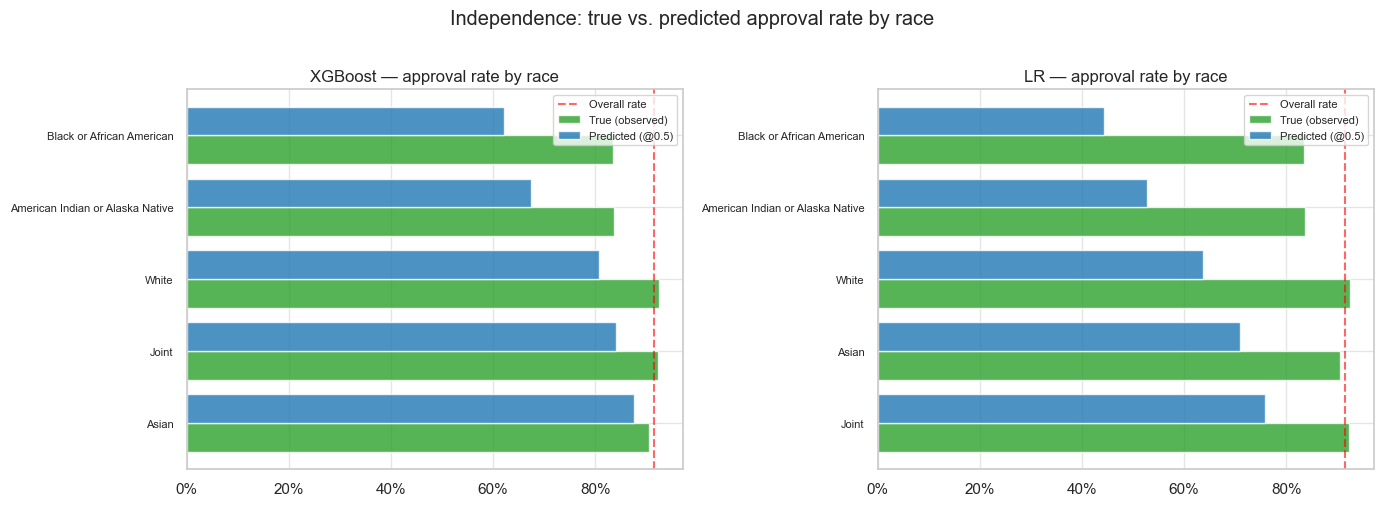

In [28]:
# ── (A) Verstärkungsanalyse: Roh-DPD vs. Modell-DPD ─────────────────────────
# Vergleicht die historische Disparität (true_approval) mit der Modell-Disparität
# (pred_approval). ΔDPD > 0: Modell verstärkt bestehende Ungleichbehandlung.
#                  ΔDPD < 0: Modell dämpft sie.

amp_rows = []
for attr in PROTECTED_ATTRS:
    dpd_hist = historical_gaps[attr]['dpd']
    dpr_hist = historical_gaps[attr]['dpr']
    row = {
        'Attribut':   attr,
        'DPD (Roh)':  dpd_hist,
        'DPR (Roh)':  dpr_hist,
    }
    for model_name, score_col, pred_col in MODELS:
        m       = fairness_metrics_full(fairness_df, attr, pred_col, score_col)
        dpd_mod = m['pred_approval'].max() - m['pred_approval'].min()
        dpr_mod = m['pred_approval'].min() / m['pred_approval'].max()
        delta   = dpd_mod - dpd_hist
        row[f'DPD ({model_name})']  = dpd_mod
        row[f'DPR ({model_name})']  = dpr_mod
        row[f'\u0394DPD ({model_name})'] = delta   # Δ
    amp_rows.append(row)

amp = pd.DataFrame(amp_rows).set_index('Attribut')

def _amp_color(val):
    """Rot = Verstärkung (ΔDPD > 0), Grün = Dämpfung (ΔDPD < 0)."""
    if val > 0.01:
        return 'background-color: #ffe0e0'
    if val < -0.01:
        return 'background-color: #d4edda'
    return ''

delta_cols = [c for c in amp.columns if c.startswith('\u0394')]  # Δ-Spalten

display(
    amp.round(3).style
    .format(lambda v: f"+{v:.3f}" if v > 0 else f"{v:.3f}",
            subset=delta_cols)
    .map(_amp_color, subset=delta_cols)
    .set_caption(
        'Verstärkungsanalyse — ΔDPD = Modell-DPD minus Roh-DPD  '
        '(rot: Modell verstärkt Disparität · grün: Modell dämpft sie)'
    )
)

# ── (B) Vollständige Fairness-Zusammenfassung: IND / SP / SF ─────────────────
rows = []
for model_name, score_col, pred_col in MODELS:
    for attr in PROTECTED_ATTRS:
        m = fairness_metrics_full(fairness_df, attr, pred_col, score_col)
        s = _fairness_scalars(m)
        rows.append({'Model': model_name, 'Attribute': attr, **s})

summary = pd.DataFrame(rows).set_index(['Model', 'Attribute'])

def _flag(val):
    return 'background-color: #ffe0e0' if val > 0.05 else ''

display(
    summary.round(3).style
    .format('{:.3f}')
    .map(_flag)
    .set_caption(
        'Fairness gaps by model and protected attribute  '
        '(IND: independence · SP: separation · SF: sufficiency) — '
        'cells > 0.05 highlighted'
    )
)

# ── (C) Bar-Chart: true vs. predicted approval rate nach Race ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, m) in zip(axes, race_metrics.items()):
    x = np.arange(len(m))
    ax.barh(x - 0.2, m['true_approval'].values, 0.4,
            label='True (observed)', color='#2ca02c', alpha=0.8)
    ax.barh(x + 0.2, m['pred_approval'].values, 0.4,
            label='Predicted (@0.5)', color='#1f77b4', alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(m.index, fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.axvline(fairness_df['target'].mean(), color='red',
               linestyle='--', alpha=0.6, label='Overall rate')
    ax.set_title(f'{model_name} — approval rate by race')
    ax.legend(fontsize=8)

plt.suptitle('Independence: true vs. predicted approval rate by race', y=1.01)
plt.tight_layout()
plt.show()


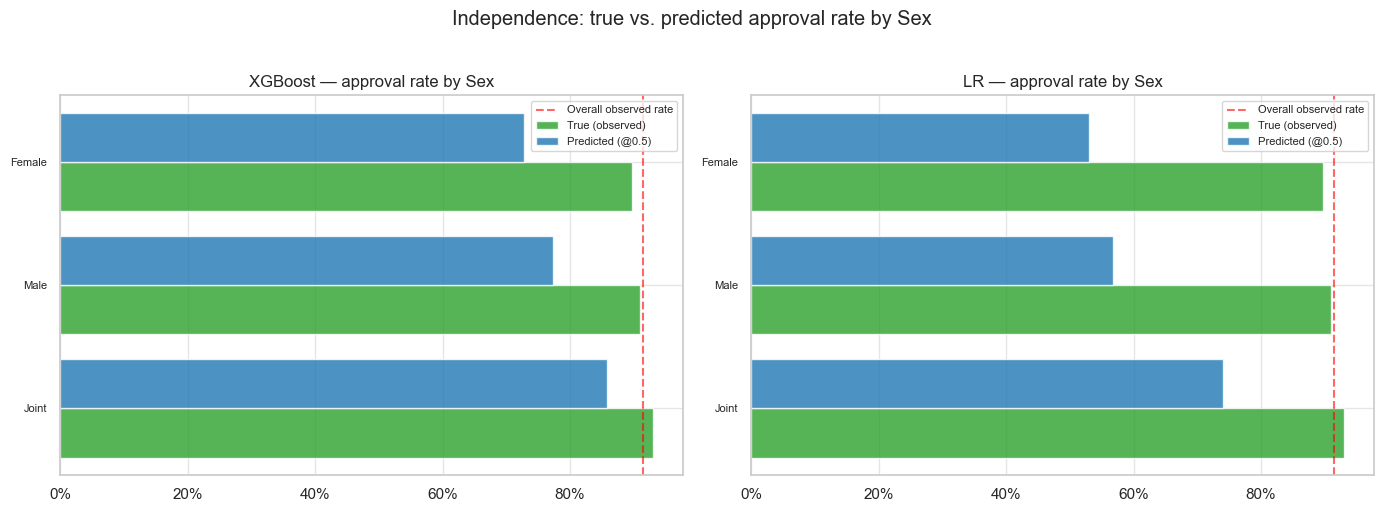

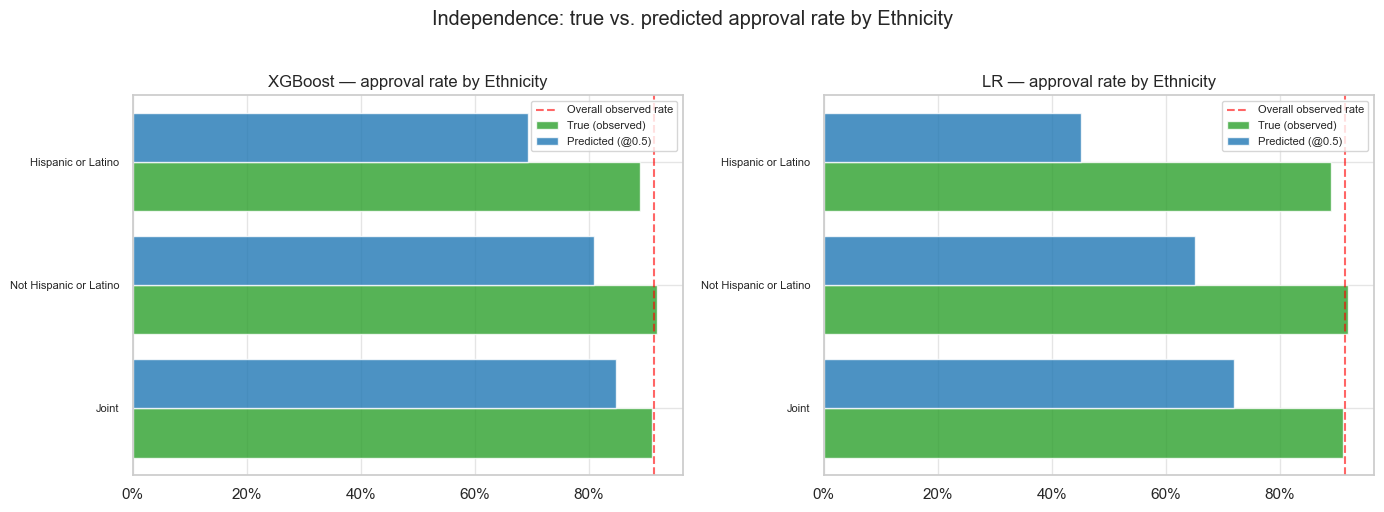

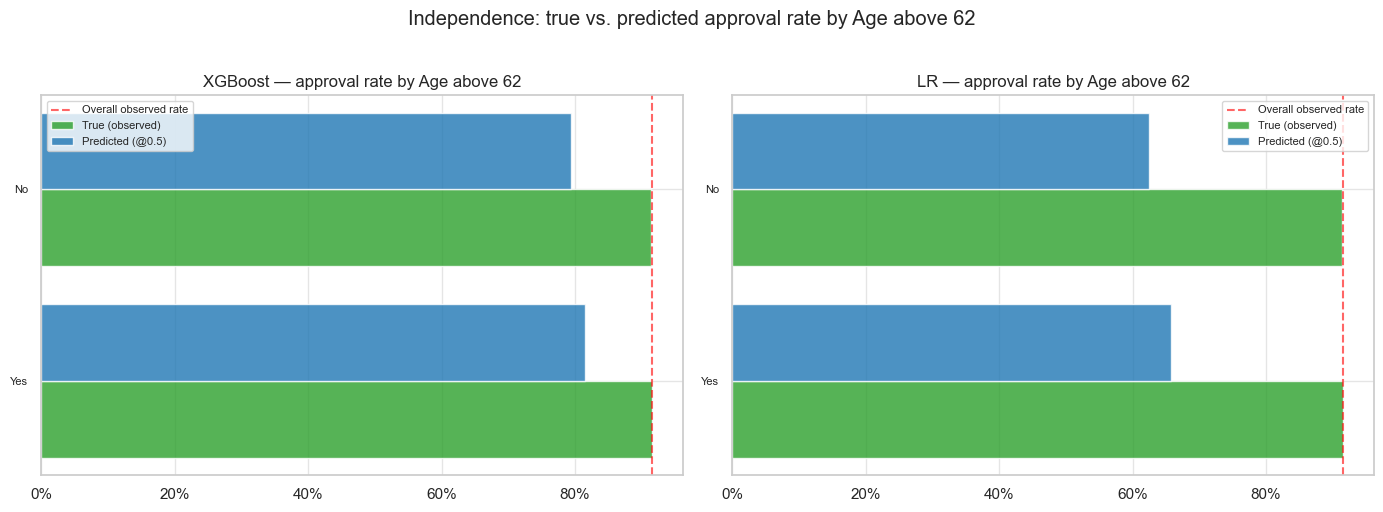

In [29]:
# ── (C2) Bar-Charts: true vs. predicted approval rate for other protected attributes ──

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

protected_metric_dicts = {
    'derived_sex': sex_metrics,
    'derived_ethnicity': ethnicity_metrics,
    'applicant_age_above_62': age62_metrics
}

protected_titles = {
    'derived_sex': 'Sex',
    'derived_ethnicity': 'Ethnicity',
    'applicant_age_above_62': 'Age above 62'
}

for attr, metric_dict in protected_metric_dicts.items():

    fig, axes = plt.subplots(1, len(metric_dict), figsize=(14, 5))

    if len(metric_dict) == 1:
        axes = [axes]

    for ax, (model_name, m) in zip(axes, metric_dict.items()):
        x = np.arange(len(m))

        ax.barh(
            x - 0.2,
            m['true_approval'].values,
            0.4,
            label='True (observed)',
            color='#2ca02c',
            alpha=0.8
        )

        ax.barh(
            x + 0.2,
            m['pred_approval'].values,
            0.4,
            label='Predicted (@0.5)',
            color='#1f77b4',
            alpha=0.8
        )

        ax.set_yticks(x)
        ax.set_yticklabels(m.index, fontsize=8)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

        ax.axvline(
            fairness_df['target'].mean(),
            color='red',
            linestyle='--',
            alpha=0.6,
            label='Overall observed rate'
        )

        ax.set_title(f"{model_name} — approval rate by {protected_titles[attr]}")
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Independence: true vs. predicted approval rate by {protected_titles[attr]}",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

# Individual Fairness
Individual fairness evaluates whether applicants with similar non-protected characteristics receive similar model predictions.
In contrast to group fairness metrics such as independence, this does not compare demographic groups directly.
Instead, we define a distance metric over legitimate applicant and loan features and check whether nearby applicants have similar predicted approval probabilities.

Because the definition of “similar applicants” is subjective, this analysis should be interpreted as an "exploratory fairness check".

In [63]:
test_idx = X_test.index

fairness_df_base = df.loc[test_idx].copy()

assert len(fairness_df_base) == len(X_test), "fairness_df_base and X_test have different lengths!"
assert len(yhat_xgb) == len(X_test), "yhat_xgb and X_test have different lengths!"
assert len(yhat_lr) == len(X_test), "yhat_lr and X_test have different lengths!"

# Add model scores and binary predictions
fairness_df_base["yhat_xgb"] = np.asarray(yhat_xgb)
fairness_df_base["pred_xgb"] = (np.asarray(yhat_xgb) >= 0.5).astype(int)

fairness_df_base["yhat_lr"] = np.asarray(yhat_lr)
fairness_df_base["pred_lr"] = (np.asarray(yhat_lr) >= 0.5).astype(int)

# Add observed bank decision
# This is the real target in our dataset: 1 = approved, 0 = denied
if "target" in fairness_df_base.columns:
    fairness_df_base["observed_bank_decision"] = fairness_df_base["target"].astype(int)
elif "loan_approved" in fairness_df_base.columns:
    fairness_df_base["observed_bank_decision"] = fairness_df_base["loan_approved"].astype(int)
else:
    fairness_df_base["observed_bank_decision"] = np.asarray(y_test).astype(int)

print("Base dataframe created.")

Base dataframe created.


In [65]:
individual_df = fairness_df_base.copy().reset_index(drop=True)

# Scores for score-based individual fairness
individual_df["score_lr"] = individual_df["yhat_lr"]
individual_df["score_xgb"] = individual_df["yhat_xgb"]

# Binary decisions for binary individual fairness
individual_df["decision_bank"] = individual_df["observed_bank_decision"].astype(int)
individual_df["decision_lr"] = individual_df["pred_lr"].astype(int)
individual_df["decision_xgb"] = individual_df["pred_xgb"].astype(int)

print("individual_df shape:", individual_df.shape)


individual_df shape: (35851, 52)


In [ ]:
# We define similarity using applicant, loan, and geographic features, excluding protected attributes from the similarity definition.

PROTECTED_ATTRS = [
    "derived_race",
    "derived_sex",
    "derived_ethnicity",
    "applicant_age_above_62"
]

CANDIDATE_SIMILARITY_FEATURES = [
    "loan_amount",
    "income",
    "loan_type",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "debt_to_income_ratio",
    "loan_to_value_ratio",
    "property_value",
    # "applicant_age",  # optional: exclude if age is treated as protected/sensitive
    "state_code",
    "county_code",
    "tract_population",
    "tract_to_msa_income_percentage",
    "ffiec_msa_md_median_family_income"
]

SIMILARITY_FEATURES = [
    col for col in CANDIDATE_SIMILARITY_FEATURES
    if col in individual_df.columns and col not in PROTECTED_ATTRS
]

print("Similarity features used:")
for col in SIMILARITY_FEATURES:
    print("-", col)

Similarity features used:
- loan_amount
- income
- loan_type
- debt_to_income_ratio
- loan_to_value_ratio
- property_value
- state_code
- county_code
- tract_population
- tract_to_msa_income_percentage
- tract_minority_population_percent
- ffiec_msa_md_median_family_income


In [68]:
#use sample of the data

IF_SAMPLE_SIZE = 10_000

if len(individual_df) > IF_SAMPLE_SIZE:
    individual_sample = individual_df.sample(
        n=IF_SAMPLE_SIZE,
        random_state=42
    ).reset_index(drop=True)
else:
    individual_sample = individual_df.copy().reset_index(drop=True)

print("Individual fairness sample shape:", individual_sample.shape)

Individual fairness sample shape: (10000, 52)


In [ ]:
#Preprocess similarity features
X_similarity = individual_sample[SIMILARITY_FEATURES].copy()

# Replace special missing values
missing_like_values = [
    "Exempt",
    "NA",
    "N/A",
    "NaN",
    "",
    " "
]

X_similarity = X_similarity.replace(missing_like_values, np.nan)

# Convert known numeric columns that may be stored as strings
NUMERIC_CANDIDATES = [
    "loan_amount",
    "income",
    "loan_to_value_ratio",
    "property_value",
    "tract_population",
    "tract_to_msa_income_percentage",
    "ffiec_msa_md_median_family_income"
]

for col in NUMERIC_CANDIDATES:
    if col in X_similarity.columns:
        X_similarity[col] = pd.to_numeric(X_similarity[col], errors="coerce")

numeric_similarity_features = X_similarity.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_similarity_features = [
    col for col in X_similarity.columns
    if col not in numeric_similarity_features
]

print("Numeric similarity features:")
print(numeric_similarity_features)

print("\nCategorical similarity features:")
print(categorical_similarity_features)

numeric_similarity_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_similarity_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

similarity_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_similarity_transformer, numeric_similarity_features),
        ("cat", categorical_similarity_transformer, categorical_similarity_features)
    ]
)

X_similarity_processed = similarity_preprocessor.fit_transform(X_similarity)

print("\nProcessed similarity matrix shape:", X_similarity_processed.shape)

Numeric similarity features:
['loan_amount', 'income', 'loan_type', 'loan_to_value_ratio', 'property_value', 'tract_population', 'tract_to_msa_income_percentage', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income']

Categorical similarity features:
['debt_to_income_ratio', 'state_code', 'county_code']

Processed similarity matrix shape: (10000, 1655)


In [71]:
#Score-based individual fairness function using k-nearest-neighbors with k=5

def individual_fairness_knn_score(X_processed, scores, k=5):
    """
    Score-based individual fairness.

    For each applicant, find k nearest neighbors based on non-protected features.
    Then compare predicted approval probabilities.

    Lower mean_abs_score_gap = stronger individual consistency.
    """

    scores = pd.Series(scores).astype(float)

    if scores.isna().any():
        raise ValueError(
            f"Scores contain {scores.isna().sum()} missing values."
        )

    scores = scores.to_numpy()

    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean"
    )

    nn.fit(X_processed)

    distances, indices = nn.kneighbors(X_processed)

    neighbor_indices = indices[:, 1:]
    neighbor_distances = distances[:, 1:]

    own_scores = scores.reshape(-1, 1)
    neighbor_scores = scores[neighbor_indices]

    abs_score_gaps = np.abs(own_scores - neighbor_scores)

    return {
        "k": k,
        "mean_abs_score_gap": abs_score_gaps.mean(),
        "median_abs_score_gap": np.median(abs_score_gaps),
        "p90_abs_score_gap": np.percentile(abs_score_gaps, 90),
        "mean_neighbor_distance": neighbor_distances.mean()
    }

In [72]:
#binary-decision individual fairness function

def individual_fairness_knn_binary(X_processed, decisions, k=5):
    """
    Binary individual fairness.

    For each applicant, find k nearest neighbors based on non-protected features.
    Then check how often the applicant and neighbors received different decisions.

    Lower disagreement_rate = stronger individual consistency.
    """

    decisions = pd.Series(decisions).astype(float)

    if decisions.isna().any():
        raise ValueError(
            f"Decisions contain {decisions.isna().sum()} missing values."
        )

    decisions = decisions.to_numpy()

    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean"
    )

    nn.fit(X_processed)

    distances, indices = nn.kneighbors(X_processed)

    neighbor_indices = indices[:, 1:]
    neighbor_distances = distances[:, 1:]

    own_decisions = decisions.reshape(-1, 1)
    neighbor_decisions = decisions[neighbor_indices]

    disagreements = (own_decisions != neighbor_decisions).astype(int)

    return {
        "k": k,
        "disagreement_rate": disagreements.mean(),
        "median_disagreement": np.median(disagreements.mean(axis=1)),
        "p90_disagreement": np.percentile(disagreements.mean(axis=1), 90),
        "mean_neighbor_distance": neighbor_distances.mean()
    }

In [73]:
#Score-based individual fairness for LR and XGBoost (Can not be implemented for the real data, because we only have the binary decisions of the bank, we use the models
#as proxy

score_if_results = []

for model_name, score_col in [
    ("LR", "score_lr"),
    ("XGBoost", "score_xgb")
]:
    result = individual_fairness_knn_score(
        X_processed=X_similarity_processed,
        scores=individual_sample[score_col],
        k=5
    )

    result["Model"] = model_name
    score_if_results.append(result)

score_individual_fairness_results = (
    pd.DataFrame(score_if_results)
    .set_index("Model")
)

score_individual_fairness_results.round(4)

,k,mean_abs_score_gap,median_abs_score_gap,p90_abs_score_gap,mean_neighbor_distance
Model,,,,,
LR,5,0.1408,0.0925,0.3398,2.0851
XGBoost,5,0.1386,0.0842,0.3480,2.0851


In [74]:
#Binary individual fairness: observed bank decisions vs model decisions

binary_if_results = []

for source_name, decision_col in [
    ("Observed bank decisions", "decision_bank"),
    ("LR predictions", "decision_lr"),
    ("XGBoost predictions", "decision_xgb")
]:
    result = individual_fairness_knn_binary(
        X_processed=X_similarity_processed,
        decisions=individual_sample[decision_col],
        k=5
    )

    result["Decision source"] = source_name
    binary_if_results.append(result)

binary_individual_fairness_results = (
    pd.DataFrame(binary_if_results)
    .set_index("Decision source")
)

binary_individual_fairness_results.round(4)

,k,disagreement_rate,median_disagreement,p90_disagreement,mean_neighbor_distance
Decision source,,,,,
Observed bank decisions,5,0.1337,0.0,0.4,2.0851
LR predictions,5,0.2691,0.2,0.6,2.0851
XGBoost predictions,5,0.1931,0.0,0.6,2.0851


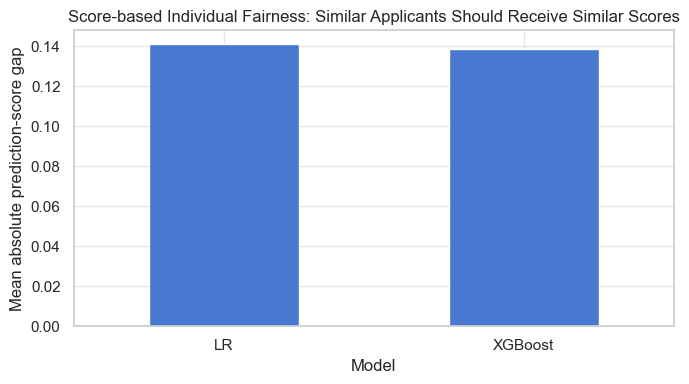

In [75]:
# Plot score-based individual fairness

import matplotlib.pyplot as plt

score_individual_fairness_results["mean_abs_score_gap"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Mean absolute prediction-score gap")
plt.title("Score-based Individual Fairness: Similar Applicants Should Receive Similar Scores")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

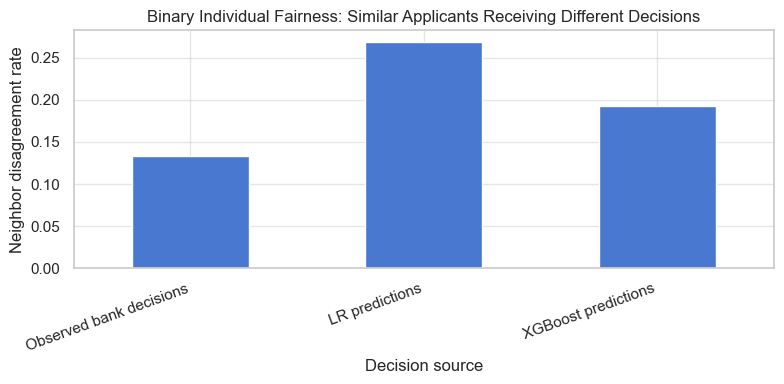

In [76]:
# Plot binary-decision individual fairness

binary_individual_fairness_results["disagreement_rate"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.ylabel("Neighbor disagreement rate")
plt.title("Binary Individual Fairness: Similar Applicants Receiving Different Decisions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [77]:
# Sensitivity analysis with different k values for the use KNN

k_values = [3, 5, 10, 20]

score_k_rows = []
binary_k_rows = []

for k in k_values:

    # Score-based model consistency
    for model_name, score_col in [
        ("LR", "score_lr"),
        ("XGBoost", "score_xgb")
    ]:
        result = individual_fairness_knn_score(
            X_processed=X_similarity_processed,
            scores=individual_sample[score_col],
            k=k
        )

        result["Model"] = model_name
        score_k_rows.append(result)

    # Binary observed/model consistency
    for source_name, decision_col in [
        ("Observed bank decisions", "decision_bank"),
        ("LR predictions", "decision_lr"),
        ("XGBoost predictions", "decision_xgb")
    ]:
        result = individual_fairness_knn_binary(
            X_processed=X_similarity_processed,
            decisions=individual_sample[decision_col],
            k=k
        )

        result["Decision source"] = source_name
        binary_k_rows.append(result)

score_if_k_results = pd.DataFrame(score_k_rows)
binary_if_k_results = pd.DataFrame(binary_k_rows)

display(score_if_k_results.round(4))
display(binary_if_k_results.round(4))

,k,mean_abs_score_gap,median_abs_score_gap,p90_abs_score_gap,mean_neighbor_distance,Model
0,3,0.1393,0.0917,0.3365,2.0000,LR
1,3,0.1370,0.0834,0.3427,2.0000,XGBoost
2,5,0.1408,0.0925,0.3398,2.0851,LR
3,5,0.1386,0.0842,0.3480,2.0851,XGBoost
4,10,0.1433,0.0944,0.3454,2.2065,LR
5,10,0.1408,0.0860,0.3523,2.2065,XGBoost
6,20,0.1451,0.0962,0.3479,2.3309,LR
7,20,0.1426,0.0875,0.3548,2.3309,XGBoost


,k,disagreement_rate,median_disagreement,p90_disagreement,mean_neighbor_distance,Decision source
0,3,0.1320,0.0000,0.3333,2.0000,Observed bank decisions
1,3,0.2651,0.3333,0.6667,2.0000,LR predictions
2,3,0.1894,0.0000,0.6667,2.0000,XGBoost predictions
3,5,0.1337,0.0000,0.4000,2.0851,Observed bank decisions
4,5,0.2691,0.2000,0.6000,2.0851,LR predictions
5,5,0.1931,0.0000,0.6000,2.0851,XGBoost predictions
6,10,0.1343,0.1000,0.3000,2.2065,Observed bank decisions
7,10,0.2734,0.2000,0.6000,2.2065,LR predictions
8,10,0.1953,0.1000,0.6000,2.2065,XGBoost predictions
9,20,0.1356,0.0500,0.2500,2.3309,Observed bank decisions


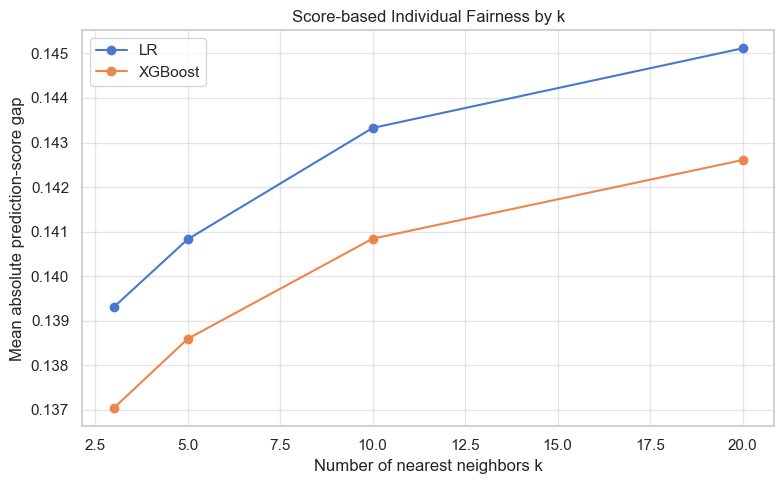

In [78]:
# Plot score sensitivity over k

plt.figure(figsize=(8, 5))

for model_name in score_if_k_results["Model"].unique():
    subset = score_if_k_results[score_if_k_results["Model"] == model_name]

    plt.plot(
        subset["k"],
        subset["mean_abs_score_gap"],
        marker="o",
        label=model_name
    )

plt.xlabel("Number of nearest neighbors k")
plt.ylabel("Mean absolute prediction-score gap")
plt.title("Score-based Individual Fairness by k")
plt.legend()
plt.tight_layout()
plt.show()

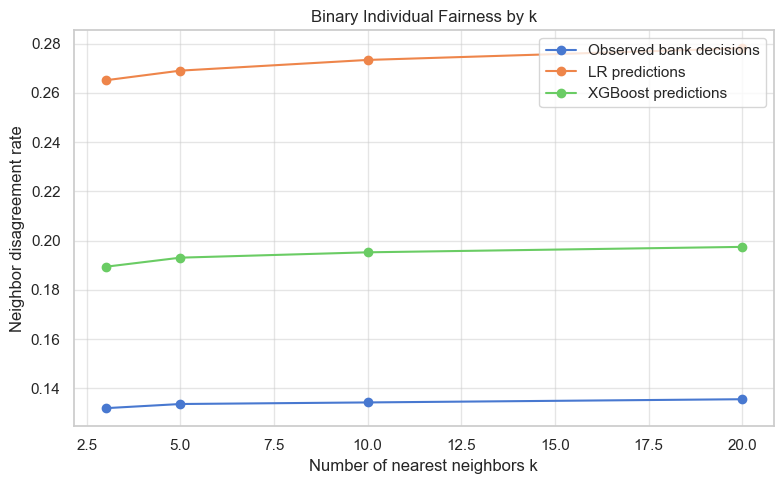

In [79]:
# Plot binary sensitivity over k

plt.figure(figsize=(8, 5))

for source_name in binary_if_k_results["Decision source"].unique():
    subset = binary_if_k_results[binary_if_k_results["Decision source"] == source_name]

    plt.plot(
        subset["k"],
        subset["disagreement_rate"],
        marker="o",
        label=source_name
    )

plt.xlabel("Number of nearest neighbors k")
plt.ylabel("Neighbor disagreement rate")
plt.title("Binary Individual Fairness by k")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation: Individual Fairness

The individual fairness analysis complements our group-level independence analysis.
While independence asks whether approval rates differ across protected groups, individual fairness asks whether similar applicants receive similar outcomes.
In other words, this analysis checks local consistency: applicants with similar observed non-protected characteristics should receive similar model scores or decisions.

We define similarity using selected applicant, loan, and geographic variables, while protected attributes are excluded from the distance calculation.
This means that the analysis does not directly test group discrimination, but rather whether the decision process treats comparable applicants consistently.

Overall, the results suggest that XGBoost performs better than Logistic Regression in terms of individual consistency. But the real banks' decisions performed better than both models.
However, individual fairness should be interpreted as an exploratory consistency measure rather than our main fairness criterion.
Our main fairness focus remains independence, because our data only contains historical bank approval decisions and not true repayment/default outcomes.
Therefore, this analysis measures whether similar applicants are treated consistently, but it does not show whether the observed or predicted decisions are objectively correct.

### 8.3 SHAP-basierte Gruppenanalyse

Treffen dieselben Features Ablehnungsentscheidungen gleich stark für weiße und nicht-weiße Antragsteller — oder gibt es systematische Gruppenunterschiede in der Feature-Attribution?

- **Mittlere |SHAP|-Werte** pro Feature, aufgeteilt nach White vs. Non-White: zeigt welche Features für welche Gruppe stärker gewichtet werden.
- **SHAP-Interaktionsplots DTI × Rasse und LTV × Rasse**: Featurewert vs. SHAP-Beitrag, farblich nach Race-Gruppe — gleiche DTI/LTV-Werte sollten zu ähnlichen SHAP-Beiträgen führen, wenn das Modell rassenneutral entscheidet.

In [ ]:
# ── Positionen von fairness_df in X_xgb_test_imp bestimmen ───────────────────
# X_xgb_test hat denselben Index wie X_test; fair_pos gibt positionale Indizes
# in X_xgb_test_imp an, die den Zeilen von fairness_df entsprechen.
idx_map_test = {label: pos for pos, label in enumerate(X_xgb_test.index)}
fair_pos     = np.array([idx_map_test[i] for i in fairness_df.index
                         if i in idx_map_test])

# Subsample aus race-getaggter Testmenge für SHAP
rng   = np.random.default_rng(42)
n_sub = min(3000, len(fair_pos))
sub   = rng.choice(len(fair_pos), n_sub, replace=False)

X_shap_g  = X_xgb_test_imp[fair_pos[sub]]
race_shap  = fairness_df.iloc[sub]['derived_race'].values

print('Computing SHAP values for group analysis...')
shap_g = explainer.shap_values(X_shap_g)   # explainer aus Section 7 wiederverwenden

# ── (A) Mittlere |SHAP|-Werte: White vs. Non-White ───────────────────────────
white_mask  = race_shap == 'White'
top_n       = 15
global_imp  = np.abs(shap_g).mean(axis=0)
top_idx     = np.argsort(global_imp)[::-1][:top_n]
top_feats   = [feat_names[i] for i in top_idx]

mean_white = np.abs(shap_g[white_mask][:, top_idx]).mean(axis=0)
mean_other = np.abs(shap_g[~white_mask][:, top_idx]).mean(axis=0)

comp = pd.DataFrame(
    {'White': mean_white, 'Non-White': mean_other}, index=top_feats
).sort_values('White', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(comp))
ax.barh(x - 0.2, comp['White'].values,     0.4, label='White',
        color='#1f77b4', alpha=0.85)
ax.barh(x + 0.2, comp['Non-White'].values, 0.4, label='Non-White',
        color='#d62728', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(comp.index, fontsize=9)
ax.set_xlabel('Mittlerer |SHAP|-Wert')
ax.set_title(
    'SHAP Feature Importance: White vs. Non-White Antragsteller\n'
    f'(Top {top_n} Features nach globalem mittleren |SHAP|)'
)
ax.legend()
plt.tight_layout()
plt.show()

# ── (B) SHAP-Interaktionsplots: DTI × Rasse  und  LTV × Rasse ────────────────
# Scatter: Featurewert (x) vs. SHAP-Beitrag (y), farblich nach Rasse.
# Bei rassenneutralem Modell sollten die Punktwolken beider Gruppen überlagern.
BLACK  = 'Black or African American'
groups = [('White', 'White', '#1f77b4'), ('Black or Afr. Am.', BLACK, '#d62728')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['dti_numeric', 'loan_to_value_ratio']):
    if feat not in feat_names:
        ax.text(0.5, 0.5, f'Feature "{feat}" nicht gefunden',
                ha='center', va='center', transform=ax.transAxes)
        continue
    fi = feat_names.index(feat)
    for label, race_val, color in groups:
        mask = race_shap == race_val
        if mask.sum() < 10:
            continue
        ax.scatter(X_shap_g[mask, fi], shap_g[mask, fi],
                   alpha=0.3, s=10, color=color, label=f'{label} (n={mask.sum():,})')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel(f'SHAP-Wert', fontsize=10)
    ax.set_title(f'{feat} × Rasse', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    'SHAP-Interaktionsplots: gleicher Featurewert → gleicher SHAP-Beitrag?',
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()


### 8.4 Fairness-Interventionen

Drei Klassen von Algorithmen werden evaluiert:

| Stufe | Methode | Referenz | Idee |
|---|---|---|---|
| **Pre-Processing** | Reweighing | Kamiran & Calders (2012) | Sample-Gewichte so anpassen, dass Gruppe × Outcome im Trainings-Set statistisch unabhängig werden |
| **In-Processing** | Prejudice Remover | Kamishima et al. (2012) | Logistische Regression mit Mutual-Information-Regularisierer: Verlust = Lₙᴏᴅᴜₛᴜᴉᴄ + η · |I(Ŷ; S)| |
| **Post-Processing** | Reject Option Classification | Kamiran et al. (2012) | In einer kritischen Region \|score − 0.5\| ≤ θ: benachteiligte Gruppen erhalten günstige, privilegierte Gruppen ungünstige Entscheidungen |

Alle Methoden werden auf `derived_race` konditioniert (privilegierte Gruppe: *White*). Güte jeder Intervention → **8.5** Accuracy-Fairness-Frontier.

In [70]:
# ── Geteilte Daten für alle Interventionen ────────────────────────────────────
# fair_pos wurde in 8.3 berechnet: Mapping fairness_df ↔ X_xgb_test_imp (positional).
X_fair_xgb     = X_xgb_test_imp[fair_pos]
y_fair         = fairness_df['target'].to_numpy()
race_fair      = fairness_df['derived_race'].to_numpy()
race_train_arr = df.loc[X_xgb_train.index, 'derived_race'].fillna('Unknown').to_numpy()

# LR-Features transformieren (OHE + Scaling) — wird für Prejudice Remover benötigt
prep_lr       = lr_pipeline.named_steps['prep']
X_lr_train_t  = prep_lr.transform(X_lr_train)           # numpy, (n_train, n_feat)
X_lr_fair_t   = prep_lr.transform(X_lr.loc[fairness_df.index])
race_train_lr = df.loc[X_lr_train.index, 'derived_race'].fillna('Unknown').to_numpy()

intervention_preds = {
    'XGBoost (Basis)': fairness_df['pred_xgb'].to_numpy(),
    'LR (Basis)':      fairness_df['pred_lr'].to_numpy(),
}

# ── Pre-Processing: Reweighing (Kamiran & Calders 2012) ───────────────────────
# w(g, o) = P(G=g) · P(Y=o) / P(G=g, Y=o)
# Hebt unterrepräsentierte Gruppe-×-Outcome-Kombinationen an, sodass
# G ⊥ Y im gewichteten Trainingssatz gilt.
def reweigh_weights(y, sensitive):
    y, s = np.asarray(y, dtype=float), np.asarray(sensitive)
    w    = np.ones(len(y))
    for g in np.unique(s):
        for o in (0, 1):
            mask     = (s == g) & (y == o)
            p_g, p_o = (s == g).mean(), (y == o).mean()
            p_j      = mask.mean()
            if p_j > 0:
                w[mask] = (p_g * p_o) / p_j
    return w

w_rw   = reweigh_weights(y_train, race_train_arr)
xgb_rw = xgb.XGBClassifier(**best_xgb.get_params())
xgb_rw.fit(X_xgb_train_imp, y_train, sample_weight=w_rw)
pred_rw = (xgb_rw.predict_proba(X_fair_xgb)[:, 1] >= 0.5).astype(int)
intervention_preds['XGB + Reweighing (Pre)'] = pred_rw

m_rw = fairness_metrics_full(
    pd.DataFrame({'target': y_fair, 'pred': pred_rw, 'derived_race': race_fair}),
    'derived_race', 'pred', 'pred',
)
s_rw = _fairness_scalars(m_rw)
print(f"Pre-Processing  (Reweighing)        ✓  "
      f"Gewichtsbereich [{w_rw.min():.3f}, {w_rw.max():.3f}]  "
      f"IND={s_rw['IND']:.3f}  SP={s_rw['SP']:.3f}  SF={s_rw['SF']:.3f}")


Pre-Processing  (Reweighing)        ✓  Gewichtsbereich [0.539, 1.176]  IND=0.238  SP=0.235  SF=0.050


In [ ]:
from scipy.special import expit as _sigmoid
from scipy.optimize import minimize as _sp_min

# In-Processing: Prejudice Remover 
# Minimiert:  L_logistic + η · |I(Ŷ ; S)|
# I(Ŷ ; S) = mutual information zwischen Modell-Score und Sensitive Attribute,
# approximiert mit kontinuierlichen (Soft-)Wahrscheinlichkeiten.

class PrejudiceRemover:
    """Logistic Regression + Mutual-Information fairness regularizer.

    Parameters
    ----------
    eta      : float  — Regularisierungsstärke (0 = reines LR, ↑ = fairer)
    max_iter : int    — L-BFGS-B Iterationen
    """

    def __init__(self, eta=1.0, max_iter=500):
        self.eta = eta
        self.max_iter = max_iter

    def _objective(self, w, Xb, y, s_enc, n_groups):
        p   = _sigmoid(Xb @ w)
        eps = 1e-12

        # Logistic cross-entropy
        ll = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

        # Mutual information I(Ŷ ; S) with soft labels
        p_y1 = p.mean()
        p_y0 = 1.0 - p_y1
        mi   = 0.0
        for g in range(n_groups):
            m      = s_enc == g
            if not m.any():
                continue
            p_s    = m.mean()
            p_y1_s = p[m].mean()
            p_y0_s = 1.0 - p_y1_s
            if p_y1_s > eps and p_y1 > eps:
                mi += p_s * p_y1_s * np.log(p_y1_s / (p_y1 + eps))
            if p_y0_s > eps and p_y0 > eps:
                mi += p_s * p_y0_s * np.log(p_y0_s / (p_y0 + eps))

        return ll + self.eta * abs(mi)

    def fit(self, X, y, sensitive):
        Xb              = np.column_stack([X, np.ones(len(X))])  # bias
        grp, s_enc      = np.unique(sensitive, return_inverse=True)
        self.groups_    = grp
        res             = _sp_min(
            self._objective,
            x0      = np.zeros(Xb.shape[1]),
            args    = (Xb, np.asarray(y, dtype=float), s_enc, len(grp)),
            method  = 'L-BFGS-B',
            options = {'maxiter': self.max_iter, 'ftol': 1e-6},
        )
        self.w_          = res.x
        self.converged_  = res.success
        return self

    def predict_proba(self, X):
        Xb = np.column_stack([X, np.ones(len(X))])
        p  = _sigmoid(Xb @ self.w_)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# Subsample für Trainingsgeschwindigkeit (L-BFGS-B auf 160k+ Obs. wäre langsam)
n_pr   = min(15_000, X_lr_train_t.shape[0])
idx_pr = np.random.default_rng(42).choice(X_lr_train_t.shape[0], n_pr, replace=False)
y_lr_train_np = np.asarray(y_lr_train, dtype=float)

print(f'Fitting Prejudice Remover (η=1.0) on {n_pr:,} subsampled observations...')
pr = PrejudiceRemover(eta=1.0, max_iter=500)
pr.fit(X_lr_train_t[idx_pr], y_lr_train_np[idx_pr], race_train_lr[idx_pr])
print(f'  Converged: {pr.converged_}')

pred_pr = pr.predict(X_lr_fair_t)
intervention_preds['LR + Prejudice Remover (In)'] = pred_pr

m_pr = fairness_metrics_full(
    pd.DataFrame({'target': y_fair, 'pred': pred_pr, 'derived_race': race_fair}),
    'derived_race', 'pred', 'pred',
)
s_pr = _fairness_scalars(m_pr)
print(f"In-Processing   (Prejudice Remover) ✓  "
      f"IND={s_pr['IND']:.3f}  SP={s_pr['SP']:.3f}  SF={s_pr['SF']:.3f}")


# Post-Processing: Reject Option Classification (Kamiran et al. 2012)
# Kritische Region: |score - 0.5| ≤ θ
#   • Benachteiligte Gruppe (Non-White) in CR  → favorable (1)
#   • Privilegierte Gruppe  (White)     in CR  → unfavorable (0)
# θ wird so gewählt, dass IND auf dem Trainings-Set minimiert wird.

def reject_option_classify(scores, race, privileged='White', theta=0.10):
    """ROC: flip-Regel in der kritischen Region um den Entscheidungsrand."""
    pred    = (scores >= 0.5).astype(int).copy()
    is_priv = race == privileged
    in_cr   = np.abs(scores - 0.5) <= theta
    pred[in_cr &  is_priv] = 0   # privilegiert in CR → ablehnen
    pred[in_cr & ~is_priv] = 1   # benachteiligt in CR → genehmigen
    return pred

# Optimales θ auf Trainings-Predictions bestimmen
yhat_train_xgb  = best_xgb.predict_proba(X_xgb_train_imp)[:, 1]
best_theta, best_ind_roc = 0.0, np.inf

for theta in np.linspace(0.01, 0.49, 97):
    p_try = reject_option_classify(yhat_train_xgb, race_train_arr, theta=theta)
    rates = pd.Series(p_try, dtype=float).groupby(race_train_arr).mean()
    ind   = rates.max() - rates.min()
    if ind < best_ind_roc:
        best_ind_roc, best_theta = ind, theta

print(f'Optimales θ (Training-Set): {best_theta:.3f}  →  IND(train)={best_ind_roc:.3f}')

# Auf Test-Set anwenden
yhat_fair_xgb = best_xgb.predict_proba(X_fair_xgb)[:, 1]
pred_roc = reject_option_classify(yhat_fair_xgb, race_fair, theta=best_theta)
intervention_preds['XGB + Reject Option (Post)'] = pred_roc

m_roc = fairness_metrics_full(
    pd.DataFrame({'target': y_fair, 'pred': pred_roc, 'derived_race': race_fair}),
    'derived_race', 'pred', 'pred',
)
s_roc = _fairness_scalars(m_roc)
print(f"Post-Processing (Reject Option)     ✓  "
      f"IND={s_roc['IND']:.3f}  SP={s_roc['SP']:.3f}  SF={s_roc['SF']:.3f}")
# check post-processing again 


Fitting Prejudice Remover (η=1.0) on 15,000 subsampled observations...
  Converged: True
In-Processing   (Prejudice Remover) ✓  IND=0.013  SP=0.049  SF=0.092
Optimales θ (Training-Set): 0.055  →  IND(train)=0.177
Post-Processing (Reject Option)     ✓  IND=0.189  SP=0.208  SF=0.054


In [ ]:
# critial area - check (probably not feasible)
in_cr = np.abs(yhat_fair_xgb - 0.5) <= best_theta
print(f"Antragsteller in kritischer Region: {in_cr.sum()} ({in_cr.mean():.1%})")
print(f"  davon White:     {(in_cr & (race_fair == 'White')).sum()}")
print(f"  davon Non-White: {(in_cr & (race_fair != 'White')).sum()}")

in_cr = np.abs(yhat_fair_xgb - 0.5) <= best_theta
cr_df = pd.DataFrame({'race': race_fair, 'in_cr': in_cr, 'pred': pred_roc})

print(cr_df[in_cr]['race'].value_counts(normalize=True).round(3))

before = fairness_df.groupby('derived_race')['pred_xgb'].mean()
after  = pd.Series(pred_roc, index=fairness_df.index
         ).groupby(race_fair).mean()

print(pd.DataFrame({'vor ROC': before, 'nach ROC': after}).round(3))

Antragsteller in kritischer Region: 3983 (12.8%)
  davon White:     3063
  davon Non-White: 920
race
White                                        0.769
Black or African American                    0.147
Asian                                        0.048
Joint                                        0.021
American Indian or Alaska Native             0.010
2 or more minority races                     0.003
Native Hawaiian or Other Pacific Islander    0.002
Name: proportion, dtype: float64
                                           vor ROC  nach ROC
2 or more minority races                     0.562     0.644
American Indian or Alaska Native             0.720     0.824
Asian                                        0.887     0.918
Black or African American                    0.638     0.736
Joint                                        0.886     0.925
Native Hawaiian or Other Pacific Islander    0.718     0.761
White                                        0.810     0.739


In [ ]:
def _frontier_point(pred, y_true, race):
    """Accuracy (vs. historische Labels) und IND (DPD nach Race)."""
    pred  = np.asarray(pred)
    acc   = (pred == y_true).mean()
    rates = pd.Series(pred).groupby(race).mean()
    ind   = rates.max() - rates.min()
    return {'Accuracy': acc, 'IND': ind}

# Punkte für alle Modelle / Interventionen berechnen
pts = pd.DataFrame({
    name: _frontier_point(pred, y_fair, race_fair)
    for name, pred in intervention_preds.items()
}).T.astype(float)

# Pareto-Dominanz: Punkt i wird dominiert, wenn es j gibt mit
# acc[j] >= acc[i] UND ind[j] <= ind[i] (mindestens eine strikt)
def is_dominated(i, df):
    for j in df.index:
        if j == i:
            continue
        if (df.loc[j, 'Accuracy'] >= df.loc[i, 'Accuracy'] and
                df.loc[j, 'IND'] <= df.loc[i, 'IND'] and
                (df.loc[j, 'Accuracy'] > df.loc[i, 'Accuracy'] or
                 df.loc[j, 'IND'] < df.loc[i, 'IND'])):
            return True
    return False

pts['dominated'] = [is_dominated(i, pts) for i in pts.index]
pareto = pts[~pts['dominated']].sort_values('IND')

# ── Plot ───────────────────────────────────────────────────────────────────────
style_map = {
    'XGBoost (Basis)':              ('o', '#1f77b4'),
    'LR (Basis)':                   ('s', '#ff7f0e'),
    'XGB + Reweighing (Pre)':       ('^', '#2ca02c'),
    'LR + Prejudice Remover (In)':  ('D', '#9467bd'),
    'XGB + Reject Option (Post)':   ('P', '#d62728'),
}

fig, ax = plt.subplots(figsize=(9, 6))

for name, row in pts.iterrows():
    marker, color = style_map.get(name, ('o', 'gray'))
    edge   = 'black' if not row['dominated'] else 'none'
    zorder = 5       if not row['dominated'] else 3
    ax.scatter(row['IND'], row['Accuracy'],
               s=130, marker=marker, color=color,
               edgecolors=edge, linewidths=1.5, zorder=zorder,
               label=name)
    ax.annotate(
        name, (row['IND'], row['Accuracy']),
        textcoords='offset points', xytext=(7, 3), fontsize=8
    )

if len(pareto) > 1:
    ax.plot(pareto['IND'].values, pareto['Accuracy'].values,
            color='black', linestyle='--', linewidth=1.2,
            alpha=0.55, zorder=2, label='Pareto-Frontier')

ax.set_xlabel('IND — Demographic Parity Difference  (\u2193 fairer)', fontsize=11)
ax.set_ylabel('Accuracy vs. historische Labels', fontsize=11)
ax.set_title(
    'Accuracy-Fairness Trade-off Frontier\n'
    '(umrandete Punkte = nicht dominiert; niedrigere Accuracy \u2248 mehr Bias-Korrektur)',
    fontsize=11
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

display(pts[['Accuracy', 'IND', 'dominated']].round(4))


### 8.1 Temporal Fairness Analysis

In [31]:
# Approval rate gap: White vs Black applicants over time
# Requires multi-year data — re-run SQL against hmda_all for full temporal analysis
race_year = (
    df[df['derived_race'].isin(['White', 'Black or African American'])]
    .groupby(['activity_year', 'derived_race'])['target']
    .mean().unstack()
)

if race_year.shape[1] == 2 and len(race_year) > 1:
    race_year['Gap'] = race_year['White'] - race_year['Black or African American']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    race_year[['White', 'Black or African American']].plot(ax=axes[0], marker='o')
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[0].set_title('Approval Rate by Year: White vs. Black')
    axes[0].set_xlabel('Year')
    race_year['Gap'].plot(ax=axes[1], marker='o', color='#d62728')
    axes[1].axhline(0, color='gray', linestyle='--')
    axes[1].set_title('Approval Rate Gap: White minus Black (pp)')
    axes[1].set_xlabel('Year')
    plt.tight_layout()
    plt.show()
    display(race_year.round(3))
else:
    print("Single year loaded — re-run SQL against hmda_all for temporal analysis.")

Single year loaded — re-run SQL against hmda_all for temporal analysis.


### 8.2 Geographic Fairness Analysis

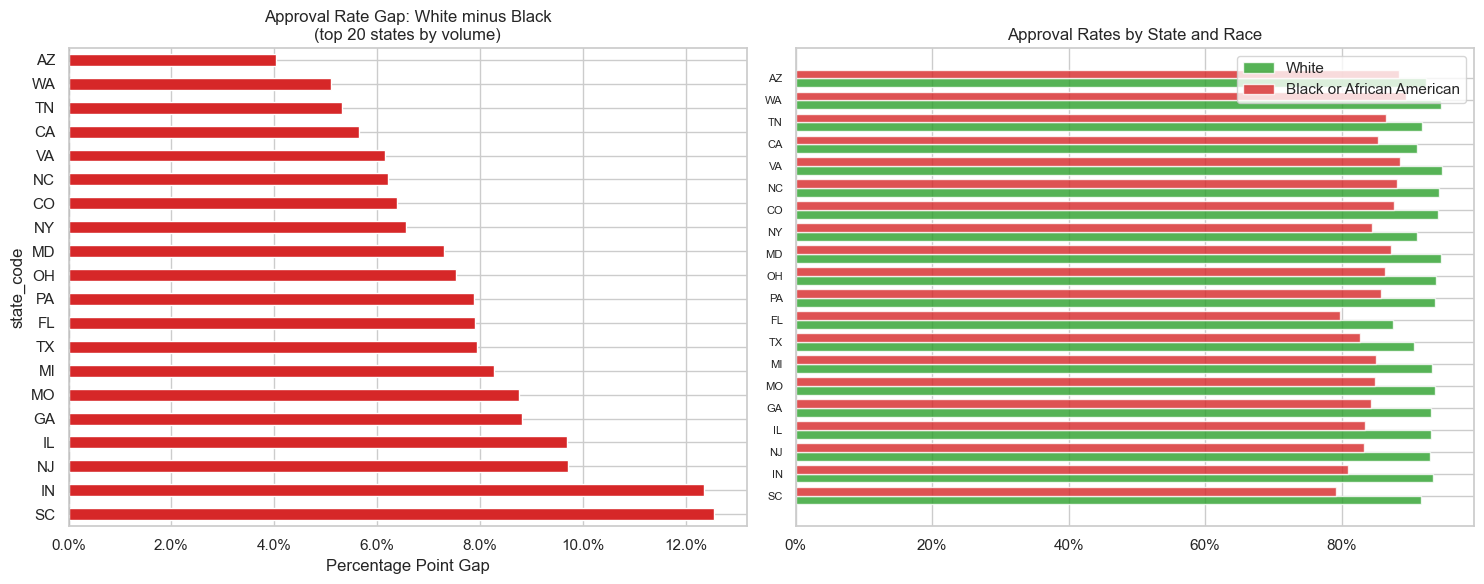

,Black or African American,White,Gap
state_code,,,
SC,0.791,0.917,0.126
IN,0.810,0.934,0.124
NJ,0.833,0.930,0.097
IL,0.834,0.931,0.097
GA,0.843,0.931,0.088
MO,0.849,0.937,0.088
MI,0.850,0.933,0.083
TX,0.827,0.906,0.079
FL,0.797,0.876,0.079


In [35]:
# Approval rate gap by state: White vs Black applicants (top 20 states by volume)
race_state = (
    df[df['derived_race'].isin(['White', 'Black or African American'])]
    .groupby(['state_code', 'derived_race'])['target']
    .mean().unstack().dropna()
)
race_state.columns.name = None
race_state['Gap'] = race_state['White'] - race_state['Black or African American']

top_states  = df.groupby('state_code')['target'].count().nlargest(20).index
race_state  = race_state.loc[race_state.index.isin(top_states)].sort_values('Gap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

race_state['Gap'].plot(kind='barh', ax=axes[0], color='#d62728', edgecolor='white')
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Approval Rate Gap: White minus Black\n(top 20 states by volume)')
axes[0].set_xlabel('Percentage Point Gap')

x = np.arange(len(race_state))
axes[1].barh(x - 0.2, race_state['White'].values, 0.4, label='White', color='#2ca02c', alpha=0.8)
axes[1].barh(x + 0.2, race_state['Black or African American'].values, 0.4,
             label='Black or African American', color='#d62728', alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(race_state.index, fontsize=8)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Approval Rates by State and Race')
axes[1].legend()

plt.tight_layout()
plt.show()
display(race_state.round(3))